## Introduction

In this post, we will look into the Fed Funds cycles and evaluate asset class performance during tightening and easing of monetary policy.

## Python Imports

In [1]:
# Standard Library
import datetime
import os
import sys
import warnings

from datetime import datetime
from pathlib import Path

# Data Handling
import numpy as np
import pandas as pd

# Data Sources
import pandas_datareader.data as web

# Statistical Analysis
import statsmodels.api as sm

# Machine Learning
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Suppress warnings
warnings.filterwarnings("ignore")

## Add Directories To Path

In [2]:
# Add the source subdirectory to the system path to allow import config from settings.py
current_directory = Path(os.getcwd())
website_base_directory = current_directory.parent.parent.parent
src_directory = website_base_directory / "src"
sys.path.append(str(src_directory)) if str(src_directory) not in sys.path else None

# Import settings.py
from settings import config

# Add configured directories from config to path
SOURCE_DIR = config("SOURCE_DIR")
sys.path.append(str(Path(SOURCE_DIR))) if str(Path(SOURCE_DIR)) not in sys.path else None

# Add other configured directories
BASE_DIR = config("BASE_DIR")
CONTENT_DIR = config("CONTENT_DIR")
POSTS_DIR = config("POSTS_DIR")
PAGES_DIR = config("PAGES_DIR")
PUBLIC_DIR = config("PUBLIC_DIR")
SOURCE_DIR = config("SOURCE_DIR")
DATA_DIR = config("DATA_DIR")
DATA_MANUAL_DIR = config("DATA_MANUAL_DIR")

## Python Functions

Here are the functions needed for this project:

* [bb_clean_data](/posts/reusable-extensible-python-functions-financial-data-analysis/#bb_clean_data): Takes an Excel export from Bloomberg, removes the miscellaneous headings/rows, and returns a DataFrame.
* [calc_fed_cycle_asset_performance](/posts/reusable-extensible-python-functions-financial-data-analysis/#calc_fed_cycle_asset_performance): Calculates metrics for an asset based on a specified Fed tightening/loosening cycle.
* [load_data](/posts/reusable-extensible-python-functions-financial-data-analysis/#load_data): Load data from a CSV, Excel, or Pickle file into a pandas DataFrame.
* [pandas_set_decimal_places](/posts/reusable-extensible-python-functions-financial-data-analysis/#pandas_set_decimal_places): Set the number of decimal places displayed for floating-point numbers in pandas.
* [plot_bar_returns_ffr_change](/posts/reusable-extensible-python-functions-financial-data-analysis/#plot_bar_returns_ffr_change): Plot the bar chart of the cumulative or annualized returns for the asset class along with the change in the Fed Funds Rate.
* [plot_scatter_regression_ffr_vs_returns](/posts/reusable-extensible-python-functions-financial-data-analysis/#plot_scatter_regression_ffr_vs_returns): Plot the scatter plot and regression of the annualized return for the asset class along with the annualized change in the Fed Funds Rate.
* [plot_timeseries](/posts/reusable-extensible-python-functions-financial-data-analysis/#plot_timeseries): Plot the timeseries data from a DataFrame for a specified date range and columns.
* [summary_stats](/posts/reusable-extensible-python-functions-financial-data-analysis/#summary_stats): Generate summary statistics for a series of returns.

In [3]:
from bb_clean_data import bb_clean_data
from calc_fed_cycle_asset_performance import calc_fed_cycle_asset_performance
from load_data import load_data
from pandas_set_decimal_places import pandas_set_decimal_places
from plot_bar_returns_ffr_change import plot_bar_returns_ffr_change
from plot_scatter_regression_ffr_vs_returns import plot_scatter_regression_ffr_vs_returns
from plot_timeseries import plot_timeseries
from summary_stats import summary_stats

## Data Overview

### Acquire & Plot Fed Funds Data

First, let's get the data for the Fed Funds target rate (FFR). This data is found in 3 different datasets from FRED.

In [4]:
# Set decimal places
pandas_set_decimal_places(5)

# Pull Federal Funds Target Rate (DISCONTINUED) (DFEDTAR)
fedfunds_target_old = web.DataReader("DFEDTAR", "fred", start="1900-01-01", end=datetime.today())

# Pull Federal Funds Target Range - Upper Limit (DFEDTARU)
fedfunds_target_new_upper = web.DataReader("DFEDTARU", "fred", start="1900-01-01", end=datetime.today())

# Pull Federal Funds Target Range - Lower Limit (DFEDTARL)
fedfunds_target_new_lower = web.DataReader("DFEDTARL", "fred", start="1900-01-01", end=datetime.today())

# Merge the datasets together
fedfunds_combined = pd.concat([fedfunds_target_old, fedfunds_target_new_upper, fedfunds_target_new_lower], axis=1)

# Divide all values by 100 to get decimal rates
for col in fedfunds_combined.columns:
    fedfunds_combined[col] = fedfunds_combined[col] / 100

# Resample to month-end (as if we know the rate at the end of the month)
fedfunds_monthly = fedfunds_combined.resample("ME").last()

display(fedfunds_monthly)

,DFEDTAR,DFEDTARU,DFEDTARL
DATE,,,
1982-09-30,0.10250,NaN,NaN
1982-10-31,0.09500,NaN,NaN
1982-11-30,0.09000,NaN,NaN
1982-12-31,0.08500,NaN,NaN
1983-01-31,0.08500,NaN,NaN
...,...,...,...
2025-10-31,NaN,0.04000,0.03750
2025-11-30,NaN,0.04000,0.03750
2025-12-31,NaN,0.03750,0.03500


We can then generate several useful plots. First, the Fed Funds target rate:

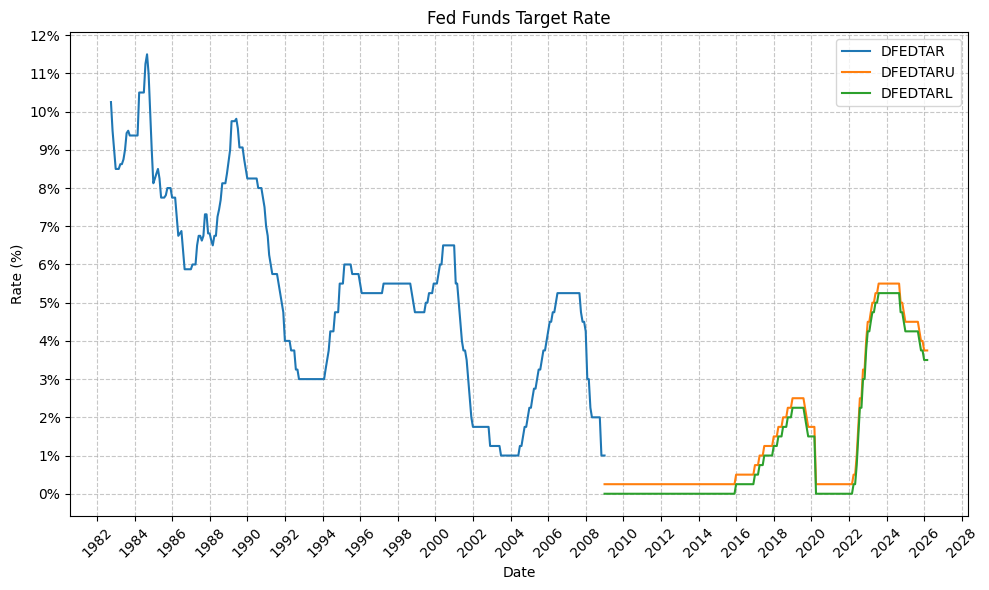

In [5]:
plot_timeseries(
    price_df=fedfunds_monthly,
    plot_start_date=None,
    plot_end_date=None,
    plot_columns=["DFEDTAR", "DFEDTARU", "DFEDTARL"],
    title="Fed Funds Target Rate",
    x_label="Date",
    x_format="Year",
    x_tick_spacing=2,
    x_tick_rotation=45,
    y_label="Rate (%)",
    y_format="Percentage",
    y_format_decimal_places=0,
    y_tick_spacing=0.01,
    grid=True,
    legend=True,
    export_plot=False,
    plot_file_name=None,
)

In [6]:
# First drop the lower column and merge
fedfunds_monthly["fed_funds"] = fedfunds_monthly["DFEDTAR"].combine_first(fedfunds_monthly["DFEDTARU"])
fedfunds_monthly = fedfunds_monthly.drop(columns=["DFEDTARL", "DFEDTARU", "DFEDTAR"])

# Compute change in rate from either column
fedfunds_monthly["fed_funds_change"] = fedfunds_monthly["fed_funds"].diff()

display(fedfunds_monthly)

,fed_funds,fed_funds_change
DATE,,
1982-09-30,0.10250,NaN
1982-10-31,0.09500,-0.00750
1982-11-30,0.09000,-0.00500
1982-12-31,0.08500,-0.00500
1983-01-31,0.08500,0.00000
...,...,...
2025-10-31,0.04000,-0.00250
2025-11-30,0.04000,0.00000
2025-12-31,0.03750,-0.00250


And then the change in FFR from month-to-month:

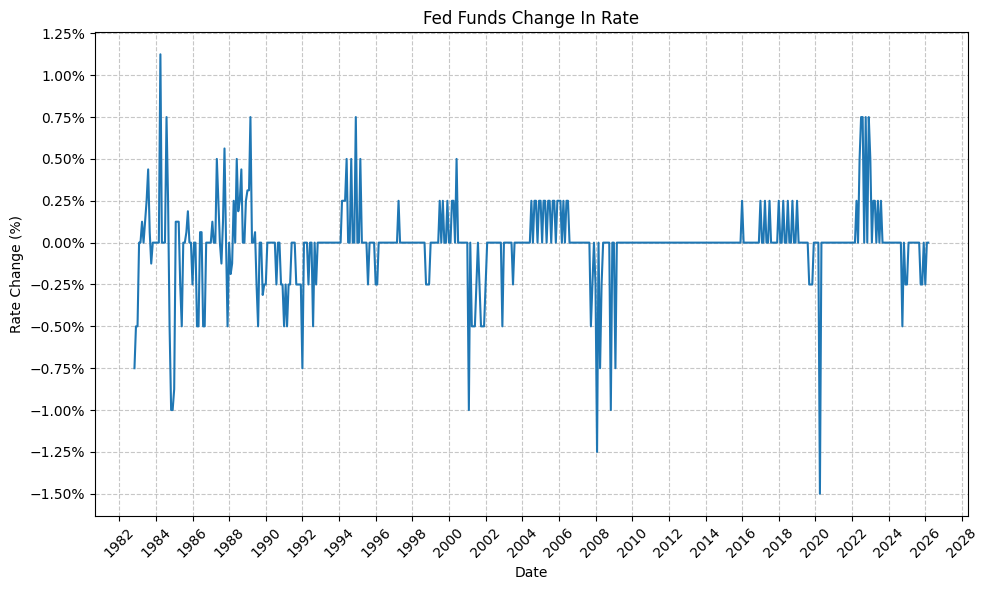

In [7]:
plot_timeseries(
    price_df=fedfunds_monthly,
    plot_start_date=None,
    plot_end_date=None,
    plot_columns=["fed_funds_change"],
    title="Fed Funds Change In Rate",
    x_label="Date",
    x_format="Year",
    x_tick_spacing=2,
    x_tick_rotation=45,
    y_label="Rate Change (%)",
    y_format="Percentage",
    y_format_decimal_places=2,
    y_tick_spacing=0.0025,
    grid=True,
    legend=False,
    export_plot=False,
    plot_file_name=None,
)

This plot, in particular, makes it easy to show the monthly increase and decrease in the FFR, as well as the magnitude of the change (i.e. slow, drawn-out increases or decreases or abrupt large increases or decreases).

### Define Fed Policy Cycles

Next, we will define the Fed policy tightening and easing cycles:

In [8]:
# Set timeframe
start_date = "1989-12-15"
end_date = "2026-01-31"

# Copy DataFrame to avoid modifying original
fedfunds_cycles = fedfunds_monthly.copy()
fedfunds_cycles = fedfunds_cycles.loc[start_date:end_date]

# Reset index
fedfunds_cycles = fedfunds_cycles.reset_index()

# Drop the "fed_funds_change" column as we will use it to determine the cycle type later, but we don't need it in the final dataframe
fedfunds_cycles = fedfunds_cycles.drop(columns=["fed_funds_change"])

# Rename the date column to "Start Date", and the "fed_funds" column to "Fed Funds Start"
fedfunds_cycles = fedfunds_cycles.rename(columns={"DATE": "start_date", "fed_funds": "fed_funds_start"})

# Copy the "Start Date" column to a new column called "End Date" and shift it up by one row
fedfunds_cycles["end_date"] = fedfunds_cycles["start_date"].shift(-1)

# Copy the "Fed Funds Start" column to a new column called "Fed Funds End" and shift it up by one row
fedfunds_cycles["fed_funds_end"] = fedfunds_cycles["fed_funds_start"].shift(-1)

# Calculate the change in Fed Funds rate for each cycle
fedfunds_cycles["fed_funds_change"] = fedfunds_cycles["fed_funds_end"] - fedfunds_cycles["fed_funds_start"]

# Based on "Fed Funds Change" column, determine if the rate is increasing, decreasing, or unchanged
fedfunds_cycles["cycle"] = fedfunds_cycles["fed_funds_change"].apply(
    lambda x: "Tightening" if x > 0 else ("Easing" if x < 0 else "Neutral"))

display(fedfunds_cycles)

,start_date,fed_funds_start,end_date,fed_funds_end,fed_funds_change,cycle
0,1989-12-31,0.08250,1990-01-31,0.08250,0.00000,Neutral
1,1990-01-31,0.08250,1990-02-28,0.08250,0.00000,Neutral
2,1990-02-28,0.08250,1990-03-31,0.08250,0.00000,Neutral
3,1990-03-31,0.08250,1990-04-30,0.08250,0.00000,Neutral
4,1990-04-30,0.08250,1990-05-31,0.08250,0.00000,Neutral
...,...,...,...,...,...,...
429,2025-09-30,0.04250,2025-10-31,0.04000,-0.00250,Easing
430,2025-10-31,0.04000,2025-11-30,0.04000,0.00000,Neutral
431,2025-11-30,0.04000,2025-12-31,0.03750,-0.00250,Easing
432,2025-12-31,0.03750,2026-01-31,0.03750,0.00000,Neutral


Grouping the consecutive months of tightening and easing together, we can create a DataFrame that gives us the cumulative change in the FFR for each cycle, as well as the start and end dates for each cycle. This will be useful for evaluating asset class performance during these cycles.

In [9]:
fedfunds_grouped_cycles = fedfunds_cycles.copy()

# Create a group key that increments whenever the Cycle value changes
fedfunds_grouped_cycles['group'] = (fedfunds_grouped_cycles['cycle'] != fedfunds_grouped_cycles['cycle'].shift(1)).cumsum()

# Group by both the group key and Cycle label
cycle_ranges = (
    fedfunds_grouped_cycles.groupby(['group', 'cycle'], sort=False)
    .agg(
        start_date=('start_date', 'first'),
        end_date=('end_date', 'last'),
        fed_funds_start=('fed_funds_start', 'first'),
        fed_funds_end=('fed_funds_end', 'last')
    )
    .reset_index(drop=False)
    .drop(columns='group')
)

display(cycle_ranges)

,cycle,start_date,end_date,fed_funds_start,fed_funds_end
0,Neutral,1989-12-31,1990-06-30,0.08250,0.08250
1,Easing,1990-06-30,1990-07-31,0.08250,0.08000
2,Neutral,1990-07-31,1990-09-30,0.08000,0.08000
3,Easing,1990-09-30,1991-04-30,0.08000,0.05750
4,Neutral,1991-04-30,1991-07-31,0.05750,0.05750
...,...,...,...,...,...
116,Neutral,2024-12-31,2025-08-31,0.04500,0.04500
117,Easing,2025-08-31,2025-10-31,0.04500,0.04000
118,Neutral,2025-10-31,2025-11-30,0.04000,0.04000
119,Easing,2025-11-30,2025-12-31,0.04000,0.03750


Furthermore, we will make the assumption that any "Neutral" months (i.e. months where the FFR did not change) are part of the preceding cycle -- to a point. For example, if we have a tightening month followed by a neutral month, we will consider the neutral month to be part of the tightening cycle. This is a simplifying assumption, but it allows us to categorize all months into either tightening or easing cycles without having to create a separate category for neutral months. From a practical standpoint, this also makes it easier to evaluate asset class performance during these cycles, as we can simply look at the performance during the tightening and easing cycles without having to worry about the neutral months. We will foward fill no more than 6 months of neutral months, however, as it would be unreasonable to assume that a month of neutral policy is part of the preceding cycle if it has been 6 months since the last change in policy.

In [10]:
fedfunds_grouped_cycles = fedfunds_cycles.copy()

# Forward fill cycle labels preceding "Neutral" cycles
fedfunds_grouped_cycles['cycle_filled'] = fedfunds_grouped_cycles['cycle'].replace('Neutral', pd.NA).ffill(limit=6)

# Replaced any remaining <NA> values with "Modified Tightening"
fedfunds_grouped_cycles['cycle_filled'] = fedfunds_grouped_cycles['cycle_filled'].fillna('Modified Tightening')

# Create a group key that increments whenever the Cycle value changes
fedfunds_grouped_cycles['group'] = (fedfunds_grouped_cycles['cycle_filled'] != fedfunds_grouped_cycles['cycle_filled'].shift(1)).cumsum()

# Group by both the group key and Cycle label
cycle_ranges = (
    fedfunds_grouped_cycles.groupby(['group', 'cycle_filled'], sort=False)
    .agg(
        start_date=('start_date', 'first'),
        end_date=('end_date', 'last'),
        fed_funds_start=('fed_funds_start', 'first'),
        fed_funds_end=('fed_funds_end', 'last')
    )
    .reset_index(drop=False)
    .drop(columns='group')
)

# Calc change in Fed Funds rate for each cycle
cycle_ranges["fed_funds_change"] = cycle_ranges["fed_funds_end"] - cycle_ranges["fed_funds_start"]

# Add cycle labels
cycle_labels = [f"Cycle {i+1}" for i in range(len(cycle_ranges))]

# Combine labels with cycle_ranges
cycle_ranges['cycle_label'] = cycle_labels

display(cycle_ranges)

,cycle_filled,start_date,end_date,fed_funds_start,fed_funds_end,fed_funds_change,cycle_label
0,Modified Tightening,1989-12-31,1990-06-30,0.08250,0.08250,0.00000,Cycle 1
1,Easing,1990-06-30,1993-03-31,0.08250,0.03000,-0.05250,Cycle 2
2,Modified Tightening,1993-03-31,1994-01-31,0.03000,0.03000,0.00000,Cycle 3
3,Tightening,1994-01-31,1995-06-30,0.03000,0.06000,0.03000,Cycle 4
4,Easing,1995-06-30,1996-07-31,0.06000,0.05250,-0.00750,Cycle 5
5,Modified Tightening,1996-07-31,1997-02-28,0.05250,0.05250,0.00000,Cycle 6
6,Tightening,1997-02-28,1997-09-30,0.05250,0.05500,0.00250,Cycle 7
7,Modified Tightening,1997-09-30,1998-08-31,0.05500,0.05500,0.00000,Cycle 8
8,Easing,1998-08-31,1999-05-31,0.05500,0.04750,-0.00750,Cycle 9
9,Tightening,1999-05-31,2000-11-30,0.04750,0.06500,0.01750,Cycle 10


## Asset Class Performance By Fed Policy Cycle

Moving on, we will now look at the performance of four (4) different asset classes during each Fed cycle. We'll use the following Bloomberg indices:

* SPXT_S&P 500 Total Return Index (Stocks)
* SPBDU10T_S&P US Treasury Bond 7-10 Year Total Return Index (Bonds)
* LF98TRUU_Bloomberg US Corporate High Yield Total Return Index Value Unhedged USD (High Yield Bonds)
* XAU_Gold USD Spot (Gold)

### Stocks

First, we will clean and load the data for the S&P 500 Total Return Index (SPXT):

In [11]:
bb_clean_data(
    base_directory=DATA_DIR,
    fund_ticker_name="SPXT_S&P 500 Total Return Index",
    source="Bloomberg",
    asset_class="Indices",
    excel_export=True,
    pickle_export=True,
    output_confirmation=False,
)

spxt = load_data(
    base_directory=DATA_DIR,
    ticker="SPXT_S&P 500 Total Return Index_Clean",
    source="Bloomberg", 
    asset_class="Indices",
    timeframe="Daily",
    file_format="pickle",
)

# Filter SPXT to date range
spxt = spxt[(spxt.index >= pd.to_datetime(start_date)) & (spxt.index <= pd.to_datetime(end_date))]

# Drop everything except the "close" column
spxt = spxt[["Close"]]

# Resample to monthly frequency
spxt_monthly = spxt.resample("M").last()
spxt_monthly["Monthly_Return"] = spxt_monthly["Close"].pct_change()
spxt_monthly = spxt_monthly.dropna()

display(spxt_monthly)

,Close,Monthly_Return
Date,,
1990-01-31,353.94000,-0.06713
1990-02-28,358.50000,0.01288
1990-03-31,368,0.02650
1990-04-30,358.81000,-0.02497
1990-05-31,393.80000,0.09752
...,...,...
2025-09-30,14826.80000,0.03650
2025-10-31,15173.95000,0.02341
2025-11-30,15211.14000,0.00245


Next, we can plot the price history before calculating the cycle performance:

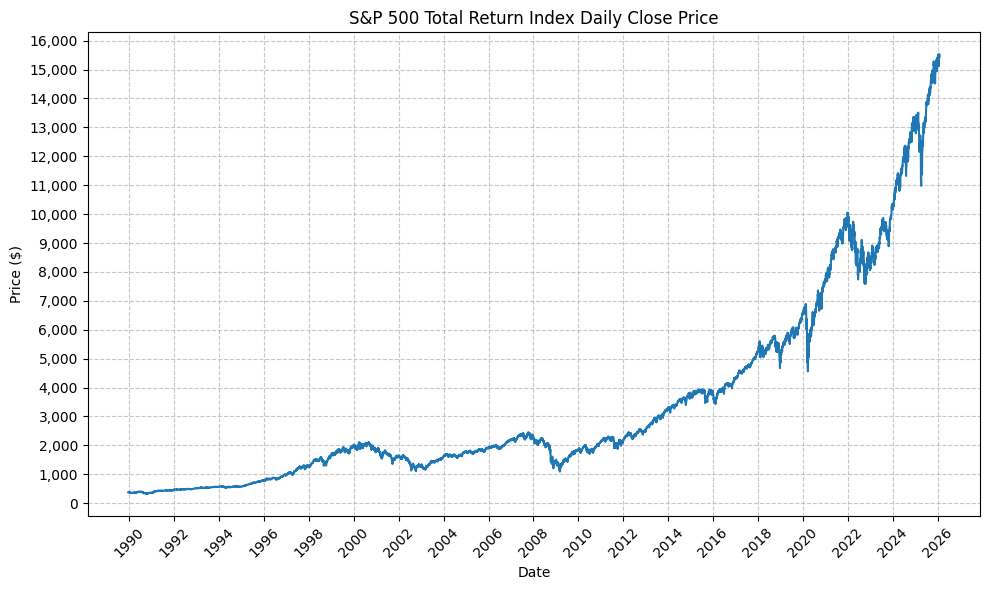

In [12]:
plot_timeseries(
    price_df=spxt,
    plot_start_date=None,
    plot_end_date=None,
    plot_columns=["Close"],
    title="S&P 500 Total Return Index Daily Close Price",
    x_label="Date",
    x_format="Year",
    x_tick_spacing=2,
    x_tick_rotation=45,
    y_label="Price ($)",
    y_format="Decimal",
    y_format_decimal_places=0,
    y_tick_spacing=1000,
    grid=True,
    legend=False,
    export_plot=False,
    plot_file_name=None,
)

Next, we will calculate the performance for SPY based on the pre-defined Fed cycles:

In [13]:
spxt_cycles = calc_fed_cycle_asset_performance(
    start_date=cycle_ranges["start_date"],
    end_date=cycle_ranges["end_date"],
    label=cycle_ranges["cycle_label"],
    fed_funds_change=cycle_ranges["fed_funds_change"],
    monthly_returns=spxt_monthly,
)

display(spxt_cycles)

,Cycle,Start,End,Months,CumulativeReturn,CumulativeReturnPct,AverageMonthlyReturn,AverageMonthlyReturnPct,AnnualizedReturn,AnnualizedReturnPct,Volatility,FedFundsChange,FedFundsChange_bps,FFR_AnnualizedChange,FFR_AnnualizedChange_bps,Label
0,Cycle 1,1989-12-31,1990-06-30,6,0.03092,3.09164,0.00634,0.63403,0.06279,6.27887,0.19170,0.00000,0.00000,0.00000,0.00000,"Cycle 1, 1989-12-31 to 1990-06-30"
1,Cycle 2,1990-06-30,1993-03-31,34,0.36800,36.80041,0.00996,0.99573,0.11694,11.69426,0.13198,-0.05250,-525.00000,-0.01853,-185.29412,"Cycle 2, 1990-06-30 to 1993-03-31"
2,Cycle 3,1993-03-31,1994-01-31,11,0.11359,11.35920,0.01001,1.00089,0.12454,12.45375,0.06918,0.00000,0.00000,0.00000,0.00000,"Cycle 3, 1993-03-31 to 1994-01-31"
3,Cycle 4,1994-01-31,1995-06-30,18,0.21800,21.80042,0.01141,1.14060,0.14051,14.05103,0.09928,0.03000,300.00000,0.02000,200.00000,"Cycle 4, 1994-01-31 to 1995-06-30"
4,Cycle 5,1995-06-30,1996-07-31,14,0.23230,23.23023,0.01527,1.52704,0.19607,19.60729,0.07840,-0.00750,-75.00000,-0.00643,-64.28571,"Cycle 5, 1995-06-30 to 1996-07-31"
5,Cycle 6,1996-07-31,1997-02-28,8,0.19592,19.59152,0.02336,2.33576,0.30783,30.78278,0.14361,0.00000,0.00000,0.00000,0.00000,"Cycle 6, 1996-07-31 to 1997-02-28"
6,Cycle 7,1997-02-28,1997-09-30,8,0.22017,22.01713,0.02631,2.63056,0.34782,34.78178,0.17547,0.00250,25.00000,0.00375,37.50000,"Cycle 7, 1997-02-28 to 1997-09-30"
7,Cycle 8,1997-09-30,1998-08-31,12,0.08094,8.09434,0.00812,0.81242,0.08094,8.09434,0.20028,0.00000,0.00000,0.00000,0.00000,"Cycle 8, 1997-09-30 to 1998-08-31"
8,Cycle 9,1998-08-31,1999-05-31,10,0.17553,17.55334,0.01849,1.84915,0.21418,21.41769,0.23543,-0.00750,-75.00000,-0.00900,-90.00000,"Cycle 9, 1998-08-31 to 1999-05-31"
9,Cycle 10,1999-05-31,2000-11-30,19,0.00401,0.40140,0.00127,0.12700,0.00253,0.25333,0.16483,0.01750,175.00000,0.01105,110.52632,"Cycle 10, 1999-05-31 to 2000-11-30"


This gives us the following data points:

* Cycle start date
* Cycle end date
* Number of months in the cycle
* Cumulative return during the cycle (decimal and percent)
* Average monthly return during the cycle (decimal and percent)
* Annualized return during the cycle (decimal and percent)
* Return volatility during the cycle
* Cumulative change in FFR during the cycle (decimal and basis points)
* Annualized change in FFR during the cycle (decimal and basis points)

From the above DataFrame, we can then plot the cumulative and annualized returns for each cycle in a bar chart. First, the cumulative returns along with the cumulative change in FFR:

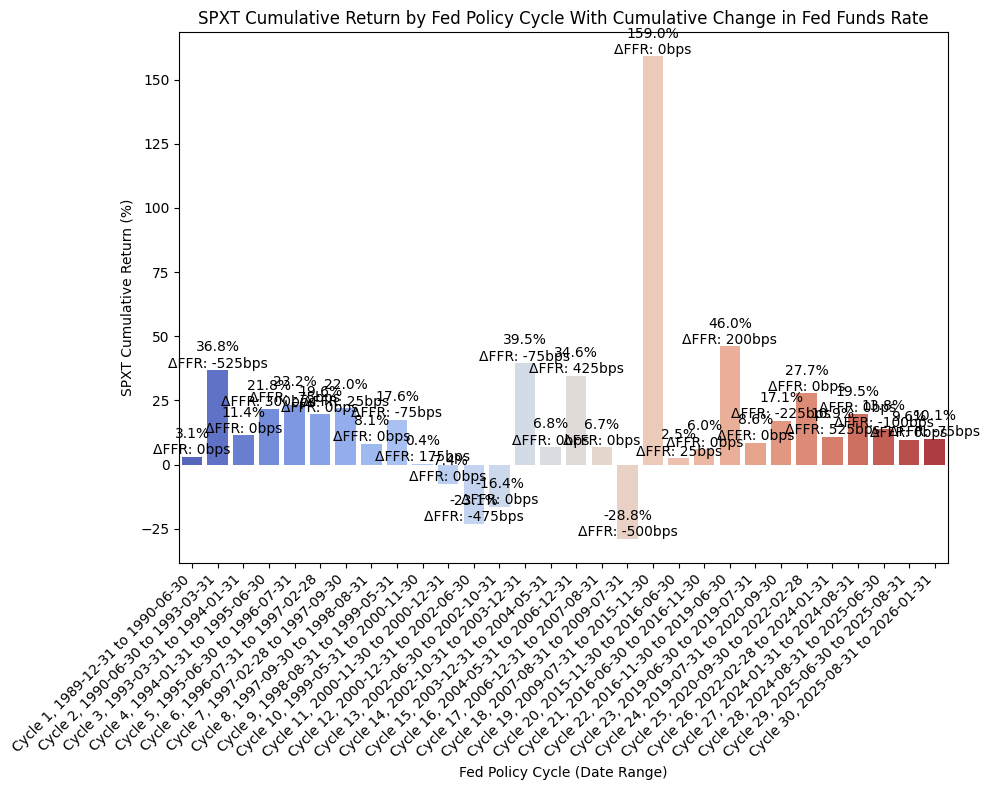

In [14]:
plot_bar_returns_ffr_change(
    cycle_df=spxt_cycles,
    asset_label="SPXT",
    annualized_or_cumulative="Cumulative",
)

And then the annualized returns along with the annualized change in FFR:

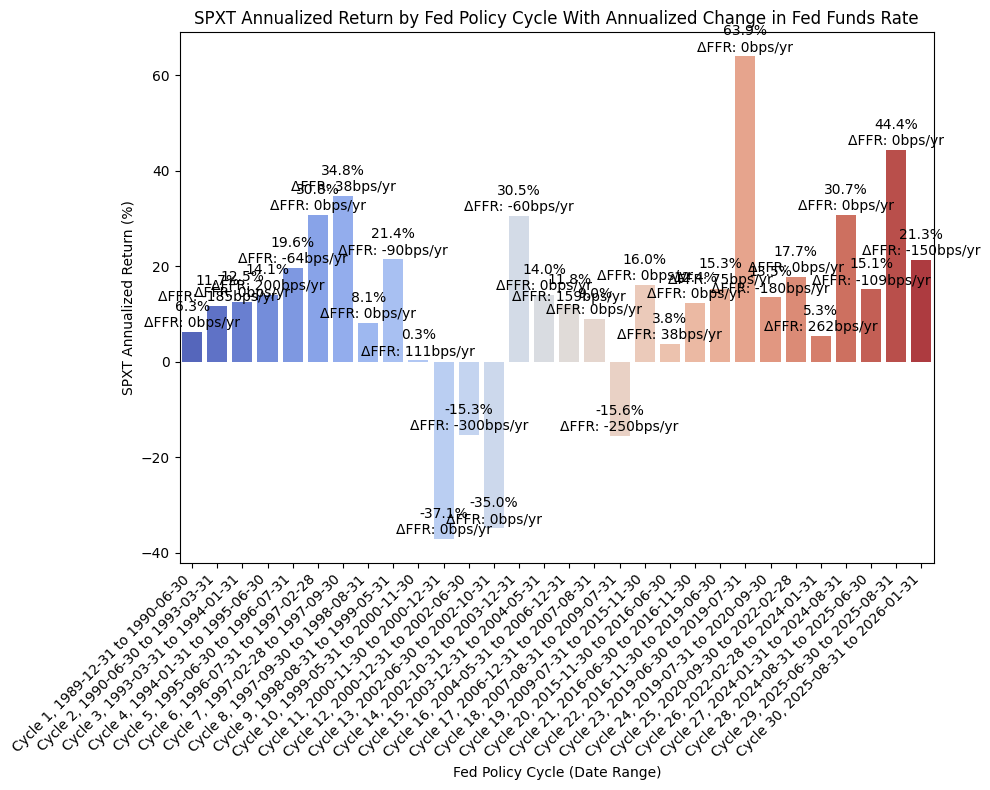

In [15]:
plot_bar_returns_ffr_change(
    cycle_df=spxt_cycles,
    asset_label="SPXT",
    annualized_or_cumulative="Annualized",
)

The cumulative returns plot is not particularly insightful, but there are some interesting observations to be gained from the annualized returns plot. During the past two (2) rate cutting cycles (cycles 11/12/13/14 and 18), stocks have exhibited negative returns during the rate cutting cycle. However, after the rate cutting cycle was complete, returns during the following cycle (when rates were usually flat) were quite strong and higher than the historical mean return for the S&P 500. The economic intuition for this behavior is valid; as the economy weakens, investors are concerned about the pricing of equities, the returns become negative, and the Fed responds with cutting rates. The exact timing of when the Fed begins cutting rates is one of the unknowns; the Fed could be ahead of the curve, cutting rates as economic data begins to prompt that action, or behind the curve, where the ecomony rolls over rapidly and even the Fed's actions are not enough to halt the economic contraction.

Finally, we can run an OLS regression to check fit:

In [16]:
df = spxt_cycles

#=== Don't modify below this line ===

# Run OLS regression with statsmodels
X = df["FFR_AnnualizedChange_bps"]
y = df["AnnualizedReturnPct"]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())
print(f"Intercept: {model.params[0]}, Slope: {model.params[1]}")  # Intercept and slope

# Calc X and Y values for regression line
X_vals = np.linspace(X.min(), X.max(), 100)
Y_vals = model.params[0] + model.params[1] * X_vals

                             OLS Regression Results                            
Dep. Variable:     AnnualizedReturnPct   R-squared:                       0.017
Model:                             OLS   Adj. R-squared:                 -0.018
Method:                  Least Squares   F-statistic:                    0.4786
Date:                 Tue, 24 Feb 2026   Prob (F-statistic):              0.495
Time:                         14:11:31   Log-Likelihood:                -132.24
No. Observations:                   30   AIC:                             268.5
Df Residuals:                       28   BIC:                             271.3
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const         

And then plot the regression line along with the values:

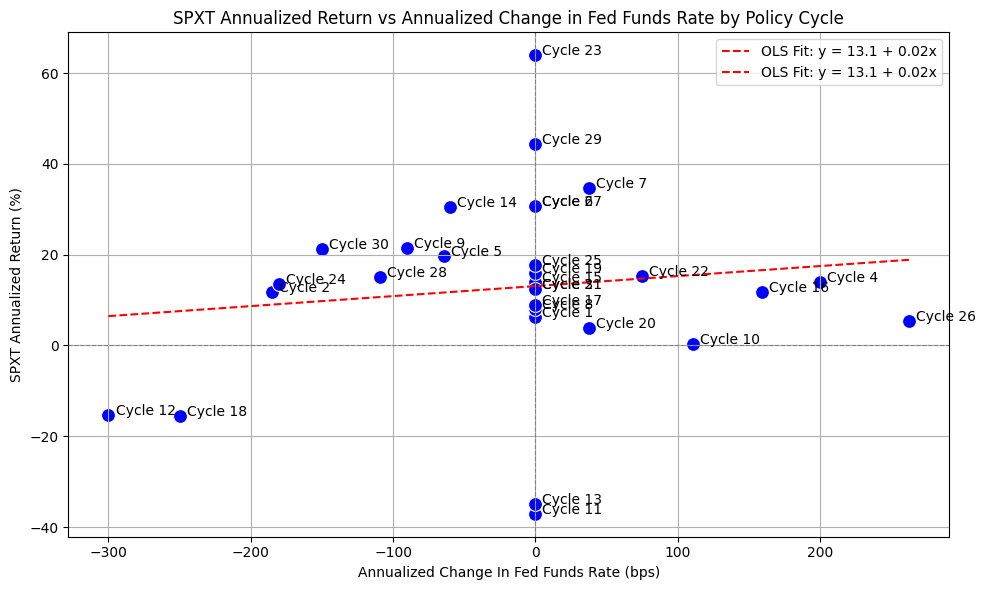

In [17]:
plot_scatter_regression_ffr_vs_returns(
    cycle_df=spxt_cycles,
    asset_label="SPXT",
    x_vals=X_vals,
    y_vals=Y_vals,
    intercept=model.params[0],
    slope=model.params[1],
)

Here we can see the data points for cycles 11/12/13/14 and 18 as mentioned above. Interestingly, cycles 28/29/30 (which is the current rate cutting cycle) appears to be an outlier. Of course, the book is not yet finished for cycles 28/29/30, and we could certainly see a bear market in stocks over the next several years.

### Bonds

Next, we'll run a similar process for medium term bonds using SPBDU10T_S&P US Treasury Bond 7-10 Year Total Return Index.

First, we pull data with the following:

In [18]:
bb_clean_data(
    base_directory=DATA_DIR,
    fund_ticker_name="SPBDU10T_S&P US Treasury Bond 7-10 Year Total Return Index",
    source="Bloomberg",
    asset_class="Indices",
    excel_export=True,
    pickle_export=True,
    output_confirmation=False,
)

treas_10y = load_data(
    base_directory=DATA_DIR,
    ticker="SPBDU10T_S&P US Treasury Bond 7-10 Year Total Return Index_Clean",
    source="Bloomberg", 
    asset_class="Indices",
    timeframe="Daily",
    file_format="pickle",
)

# Filter TREAS_10Y to date range
treas_10y = treas_10y[(treas_10y.index >= pd.to_datetime(start_date)) & (treas_10y.index <= pd.to_datetime(end_date))]

# Drop everything except the "close" column
treas_10y = treas_10y[["Close"]]

# Resample to monthly frequency
treas_10y_monthly = treas_10y.resample("M").last()
treas_10y_monthly["Monthly_Return"] = treas_10y_monthly["Close"].pct_change()
treas_10y_monthly = treas_10y_monthly.dropna()

display(treas_10y_monthly)

,Close,Monthly_Return
Date,,
1990-01-31,98.01300,-0.01987
1990-02-28,97.99000,-0.00023
1990-03-31,97.98900,-0.00001
1990-04-30,96.60600,-0.01411
1990-05-31,99.64700,0.03148
...,...,...
2025-09-30,645.58400,0.00675
2025-10-31,650.00500,0.00685
2025-11-30,656.63600,0.01020


Next, we can plot the price history before calculating the cycle performance:

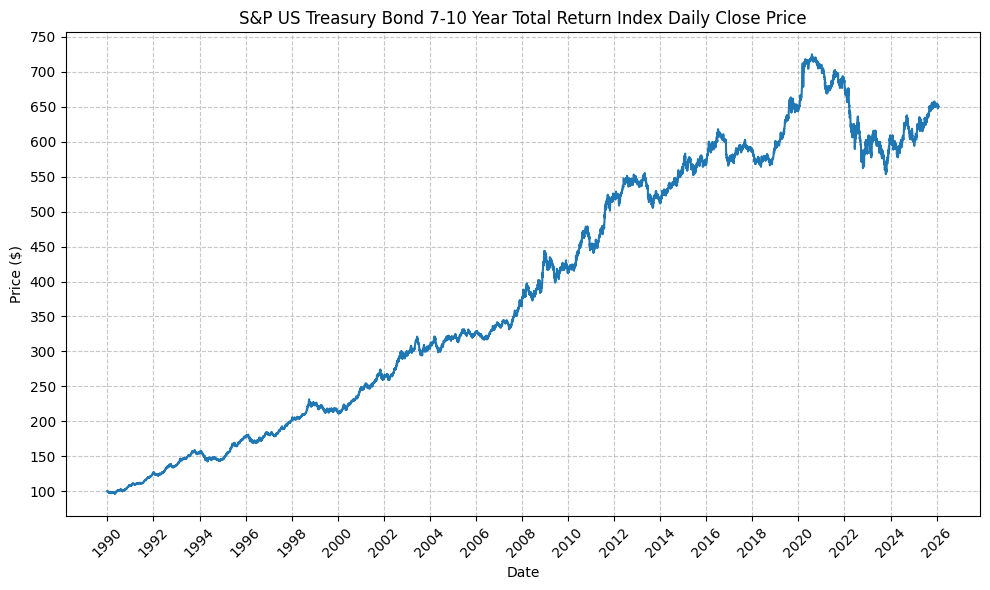

In [19]:
plot_timeseries(
    price_df=treas_10y,
    plot_start_date=None,
    plot_end_date=None,
    plot_columns=["Close"],
    title="S&P US Treasury Bond 7-10 Year Total Return Index Daily Close Price",
    x_label="Date",
    x_format="Year",
    x_tick_spacing=2,
    x_tick_rotation=45,
    y_label="Price ($)",
    y_format="Decimal",
    y_format_decimal_places=0,
    y_tick_spacing=50,
    grid=True,
    legend=False,
    export_plot=False,
    plot_file_name=None,
)

Next, we will calculate the performance for SPY based on the pre-defined Fed cycles:

In [20]:
treas_10y_cycles = calc_fed_cycle_asset_performance(
    start_date=cycle_ranges["start_date"],
    end_date=cycle_ranges["end_date"],
    label=cycle_ranges["cycle_label"],
    fed_funds_change=cycle_ranges["fed_funds_change"],
    monthly_returns=treas_10y_monthly,
)

display(treas_10y_cycles)

,Cycle,Start,End,Months,CumulativeReturn,CumulativeReturnPct,AverageMonthlyReturn,AverageMonthlyReturnPct,AnnualizedReturn,AnnualizedReturnPct,Volatility,FedFundsChange,FedFundsChange_bps,FFR_AnnualizedChange,FFR_AnnualizedChange_bps,Label
0,Cycle 1,1989-12-31,1990-06-30,6,0.01362,1.36200,0.00241,0.24101,0.02743,2.74255,0.06657,0.00000,0.00000,0.00000,0.00000,"Cycle 1, 1989-12-31 to 1990-06-30"
1,Cycle 2,1990-06-30,1993-03-31,34,0.45682,45.68226,0.01124,1.12428,0.14202,14.20180,0.05346,-0.05250,-525.00000,-0.01853,-185.29412,"Cycle 2, 1990-06-30 to 1993-03-31"
2,Cycle 3,1993-03-31,1994-01-31,11,0.08876,8.87610,0.00784,0.78356,0.09721,9.72108,0.04458,0.00000,0.00000,0.00000,0.00000,"Cycle 3, 1993-03-31 to 1994-01-31"
3,Cycle 4,1994-01-31,1995-06-30,18,0.07796,7.79638,0.00439,0.43870,0.05132,5.13229,0.07287,0.03000,300.00000,0.02000,200.00000,"Cycle 4, 1994-01-31 to 1995-06-30"
4,Cycle 5,1995-06-30,1996-07-31,14,0.04785,4.78467,0.00344,0.34387,0.04087,4.08738,0.04940,-0.00750,-75.00000,-0.00643,-64.28571,"Cycle 5, 1995-06-30 to 1996-07-31"
5,Cycle 6,1996-07-31,1997-02-28,8,0.05301,5.30118,0.00658,0.65819,0.08056,8.05623,0.05365,0.00000,0.00000,0.00000,0.00000,"Cycle 6, 1996-07-31 to 1997-02-28"
6,Cycle 7,1997-02-28,1997-09-30,8,0.06453,6.45298,0.00799,0.79904,0.09834,9.83398,0.06285,0.00250,25.00000,0.00375,37.50000,"Cycle 7, 1997-02-28 to 1997-09-30"
7,Cycle 8,1997-09-30,1998-08-31,12,0.14428,14.42797,0.01135,1.13516,0.14428,14.42797,0.03891,0.00000,0.00000,0.00000,0.00000,"Cycle 8, 1997-09-30 to 1998-08-31"
8,Cycle 9,1998-08-31,1999-05-31,10,0.03052,3.05162,0.00326,0.32630,0.03673,3.67303,0.08244,-0.00750,-75.00000,-0.00900,-90.00000,"Cycle 9, 1998-08-31 to 1999-05-31"
9,Cycle 10,1999-05-31,2000-11-30,19,0.08744,8.74418,0.00449,0.44926,0.05437,5.43706,0.04250,0.01750,175.00000,0.01105,110.52632,"Cycle 10, 1999-05-31 to 2000-11-30"


This gives us the following data points:

* Cycle start date
* Cycle end date
* Number of months in the cycle
* Cumulative return during the cycle (decimal and percent)
* Average monthly return during the cycle (decimal and percent)
* Annualized return during the cycle (decimal and percent)
* Return volatility during the cycle
* Cumulative change in FFR during the cycle (decimal and basis points)
* Annualized change in FFR during the cycle (decimal and basis points)

From the above DataFrame, we can then plot the cumulative and annualized returns for each cycle in a bar chart. First, the cumulative returns along with the cumulative change in FFR:

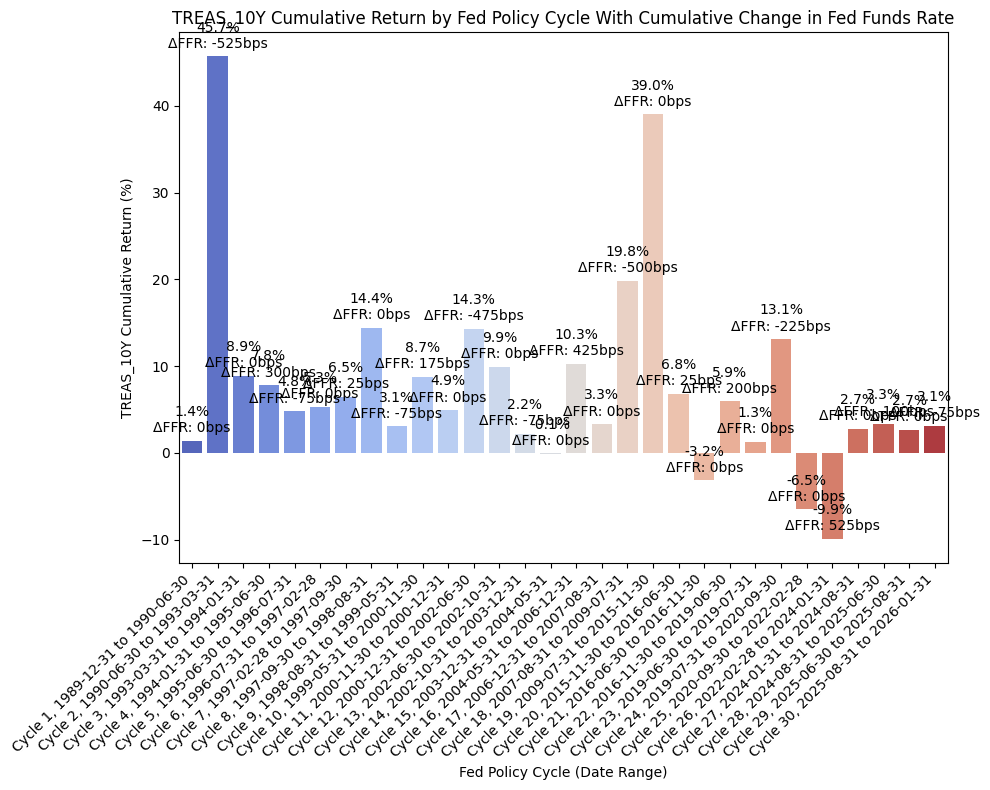

In [21]:
plot_bar_returns_ffr_change(
    cycle_df=treas_10y_cycles,
    asset_label="TREAS_10Y",
    annualized_or_cumulative="Cumulative",
)

And then the annualized returns along with the annualized change in FFR:

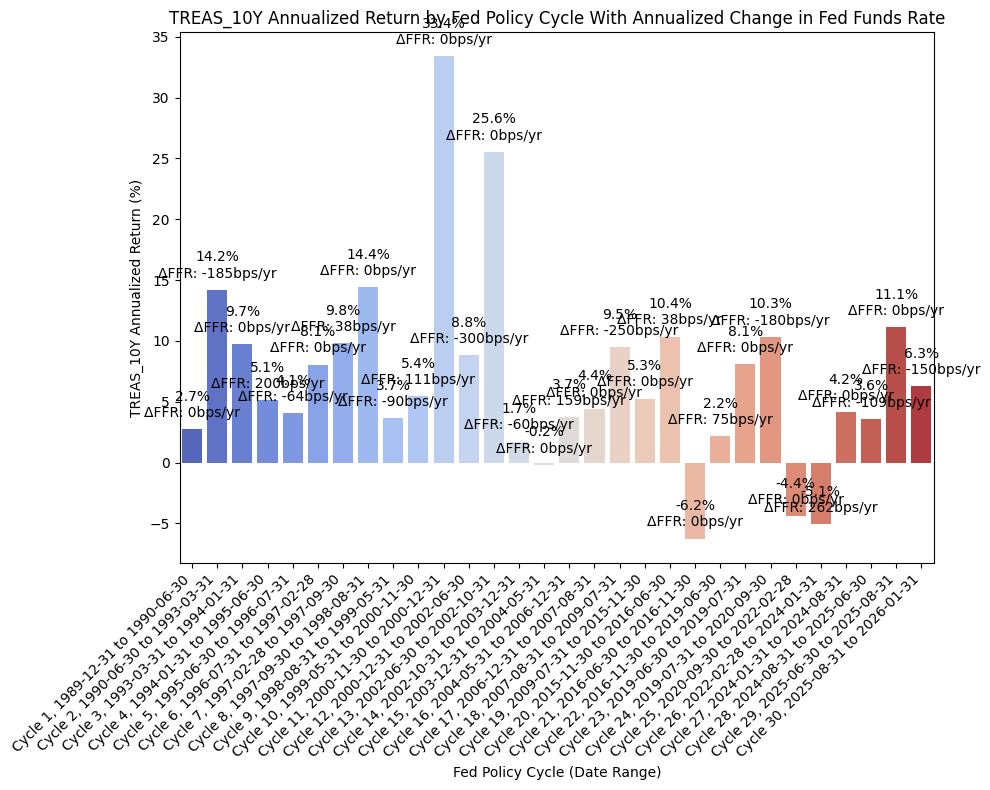

In [22]:
plot_bar_returns_ffr_change(
    cycle_df=treas_10y_cycles,
    asset_label="TREAS_10Y",
    annualized_or_cumulative="Annualized",
)

For this dataset, we have cycles 11/12/13/14 exhibiting strong returns, which is consistent with the economic intuition that bonds should perform well during periods of economic weakness and rate cuts. We also see this outcome with cycle 18. It becomes a little more interesting during cycles 25 and 26, where the correlations of stocks and bond returns seemed to align, so we see negative bond returns there. Finally, cycles 28/29/30 also exhibit positive bond returns, which is consistent with our thesis that bonds should perform well during periods of economic weakness and rate cuts.

Finally, we can run an OLS regression to check fit:

In [23]:
df = treas_10y_cycles

#=== Don't modify below this line ===

# Run OLS regression with statsmodels
X = df["FFR_AnnualizedChange_bps"]
y = df["AnnualizedReturnPct"]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())
print(f"Intercept: {model.params[0]}, Slope: {model.params[1]}")  # Intercept and slope

# Calc X and Y values for regression line
X_vals = np.linspace(X.min(), X.max(), 100)
Y_vals = model.params[0] + model.params[1] * X_vals

                             OLS Regression Results                            
Dep. Variable:     AnnualizedReturnPct   R-squared:                       0.050
Model:                             OLS   Adj. R-squared:                  0.016
Method:                  Least Squares   F-statistic:                     1.462
Date:                 Tue, 24 Feb 2026   Prob (F-statistic):              0.237
Time:                         14:11:34   Log-Likelihood:                -103.64
No. Observations:                   30   AIC:                             211.3
Df Residuals:                       28   BIC:                             214.1
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const         

And then plot the regression line along with the values:

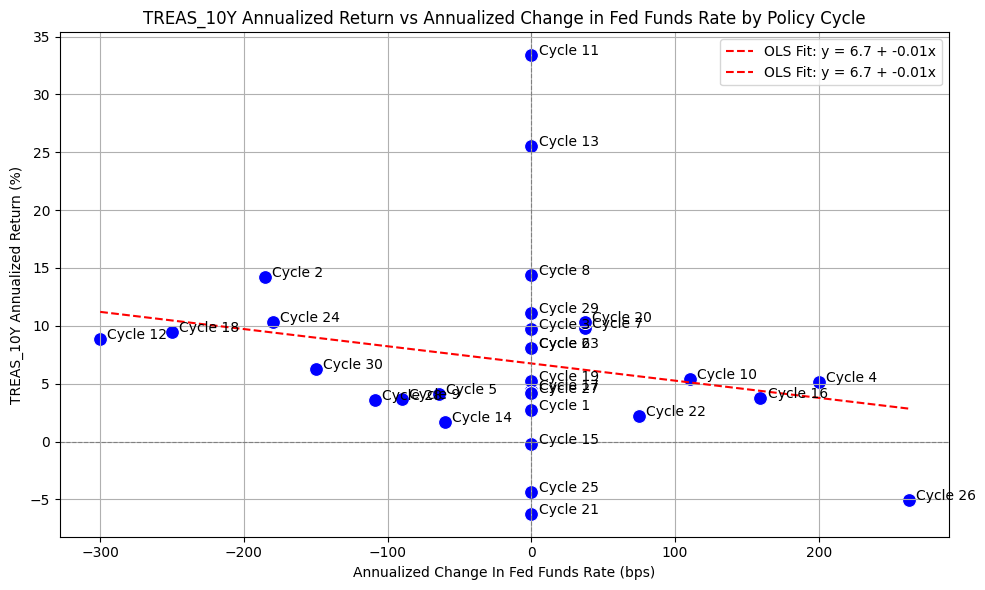

In [24]:
plot_scatter_regression_ffr_vs_returns(
    cycle_df=treas_10y_cycles,
    asset_label="TREAS_10Y",
    x_vals=X_vals,
    y_vals=Y_vals,
    intercept=model.params[0],
    slope=model.params[1],
)

The above plot is intriguing because of how well the OLS regression appears to fit the data. It certainly appears that during rate-cutting cycles, bonds are an asset that performs well.

### High Yield Bonds

Next, we'll run a similar process for high yield bonds using LF98TRUU_Bloomberg US Corporate High Yield Total Return Index Value Unhedged USD.

First, we pull data with the following:

In [25]:
bb_clean_data(
    base_directory=DATA_DIR,
    fund_ticker_name="LF98TRUU_Bloomberg US Corporate High Yield Total Return Index Value Unhedged USD",
    source="Bloomberg",
    asset_class="Indices",
    excel_export=True,
    pickle_export=True,
    output_confirmation=False,
)

hy_bonds = load_data(
    base_directory=DATA_DIR,
    ticker="LF98TRUU_Bloomberg US Corporate High Yield Total Return Index Value Unhedged USD_Clean",
    source="Bloomberg", 
    asset_class="Indices",
    timeframe="Daily",
    file_format="pickle",
)

# Filter HY_BONDS to date range
hy_bonds = hy_bonds[(hy_bonds.index >= pd.to_datetime(start_date)) & (hy_bonds.index <= pd.to_datetime(end_date))]

# Drop everything except the "close" column
hy_bonds = hy_bonds[["Close"]]

# Resample to monthly frequency
hy_bonds_monthly = hy_bonds.resample("M").last()
hy_bonds_monthly["Monthly_Return"] = hy_bonds_monthly["Close"].pct_change()
hy_bonds_monthly = hy_bonds_monthly.dropna()

display(hy_bonds_monthly)

,Close,Monthly_Return
Date,,
1990-01-31,194.21000,-0.02146
1990-02-28,190.20000,-0.02065
1990-03-31,195.19000,0.02624
1990-04-30,194.86000,-0.00169
1990-05-31,198.62000,0.01930
...,...,...
2025-09-30,2876.85000,0.00816
2025-10-31,2881.38000,0.00157
2025-11-30,2898.07000,0.00579


Next, we can plot the price history before calculating the cycle performance:

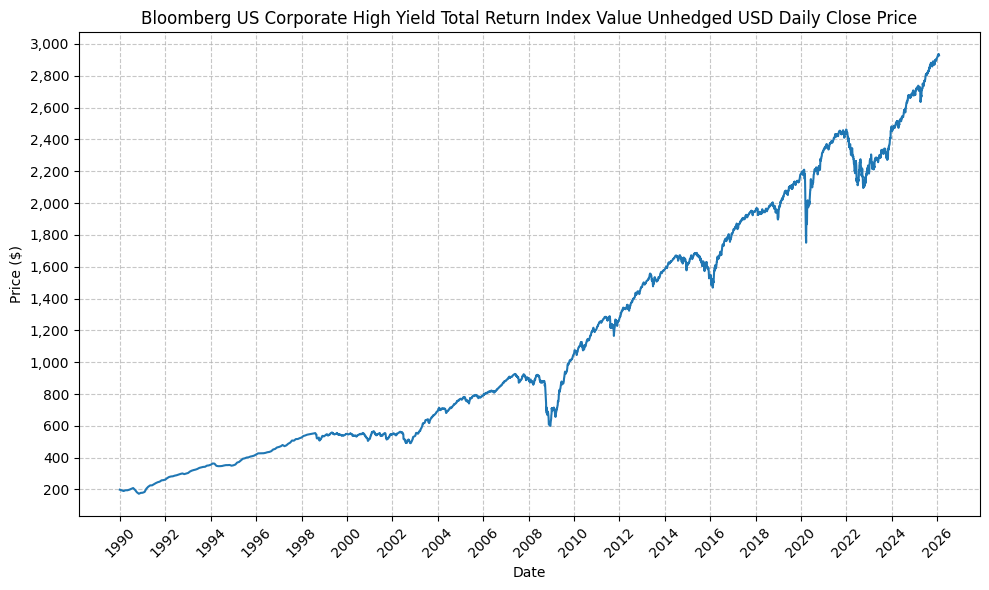

In [26]:
plot_timeseries(
    price_df=hy_bonds,
    plot_start_date=None,
    plot_end_date=None,
    plot_columns=["Close"],
    title="Bloomberg US Corporate High Yield Total Return Index Value Unhedged USD Daily Close Price",
    x_label="Date",
    x_format="Year",
    x_tick_spacing=2,
    x_tick_rotation=45,
    y_label="Price ($)",
    y_format="Decimal",
    y_format_decimal_places=0,
    y_tick_spacing=200,
    grid=True,
    legend=False,
    export_plot=False,
    plot_file_name=None,
)

Next, we will calculate the performance of high yield bonds based on the pre-defined Fed cycles:

In [27]:
hy_bonds_cycles = calc_fed_cycle_asset_performance(
    start_date=cycle_ranges["start_date"],
    end_date=cycle_ranges["end_date"],
    label=cycle_ranges["cycle_label"],
    fed_funds_change=cycle_ranges["fed_funds_change"],
    monthly_returns=hy_bonds_monthly,
)

display(hy_bonds_cycles)

,Cycle,Start,End,Months,CumulativeReturn,CumulativeReturnPct,AverageMonthlyReturn,AverageMonthlyReturnPct,AnnualizedReturn,AnnualizedReturnPct,Volatility,FedFundsChange,FedFundsChange_bps,FFR_AnnualizedChange,FFR_AnnualizedChange_bps,Label
0,Cycle 1,1989-12-31,1990-06-30,6,0.02494,2.49408,0.00432,0.43159,0.05050,5.05036,0.07625,0.00000,0.00000,0.00000,0.00000,"Cycle 1, 1989-12-31 to 1990-06-30"
1,Cycle 2,1990-06-30,1993-03-31,34,0.62149,62.14883,0.01480,1.47959,0.18601,18.60069,0.10898,-0.05250,-525.00000,-0.01853,-185.29412,"Cycle 2, 1990-06-30 to 1993-03-31"
2,Cycle 3,1993-03-31,1994-01-31,11,0.14262,14.26235,0.01221,1.22129,0.15656,15.65571,0.02227,0.00000,0.00000,0.00000,0.00000,"Cycle 3, 1993-03-31 to 1994-01-31"
3,Cycle 4,1994-01-31,1995-06-30,18,0.11254,11.25422,0.00607,0.60701,0.07369,7.36869,0.05691,0.03000,300.00000,0.02000,200.00000,"Cycle 4, 1994-01-31 to 1995-06-30"
4,Cycle 5,1995-06-30,1996-07-31,14,0.10892,10.89235,0.00743,0.74262,0.09267,9.26651,0.01906,-0.00750,-75.00000,-0.00643,-64.28571,"Cycle 5, 1995-06-30 to 1996-07-31"
5,Cycle 6,1996-07-31,1997-02-28,8,0.10479,10.47889,0.01255,1.25548,0.16123,16.12319,0.02366,0.00000,0.00000,0.00000,0.00000,"Cycle 6, 1996-07-31 to 1997-02-28"
6,Cycle 7,1997-02-28,1997-09-30,8,0.09557,9.55703,0.01156,1.15581,0.14673,14.67279,0.04792,0.00250,25.00000,0.00375,37.50000,"Cycle 7, 1997-02-28 to 1997-09-30"
7,Cycle 8,1997-09-30,1998-08-31,12,0.03219,3.21938,0.00282,0.28169,0.03219,3.21938,0.06631,0.00000,0.00000,0.00000,0.00000,"Cycle 8, 1997-09-30 to 1998-08-31"
8,Cycle 9,1998-08-31,1999-05-31,10,-0.00728,-0.72813,-0.00042,-0.04217,-0.00873,-0.87312,0.09026,-0.00750,-75.00000,-0.00900,-90.00000,"Cycle 9, 1998-08-31 to 1999-05-31"
9,Cycle 10,1999-05-31,2000-11-30,19,-0.08916,-8.91594,-0.00480,-0.47963,-0.05728,-5.72758,0.05172,0.01750,175.00000,0.01105,110.52632,"Cycle 10, 1999-05-31 to 2000-11-30"


This gives us the following data points:

* Cycle start date
* Cycle end date
* Number of months in the cycle
* Cumulative return during the cycle (decimal and percent)
* Average monthly return during the cycle (decimal and percent)
* Annualized return during the cycle (decimal and percent)
* Return volatility during the cycle
* Cumulative change in FFR during the cycle (decimal and basis points)
* Annualized change in FFR during the cycle (decimal and basis points)

From the above DataFrame, we can then plot the cumulative and annualized returns for each cycle in a bar chart. First, the cumulative returns along with the cumulative change in FFR:

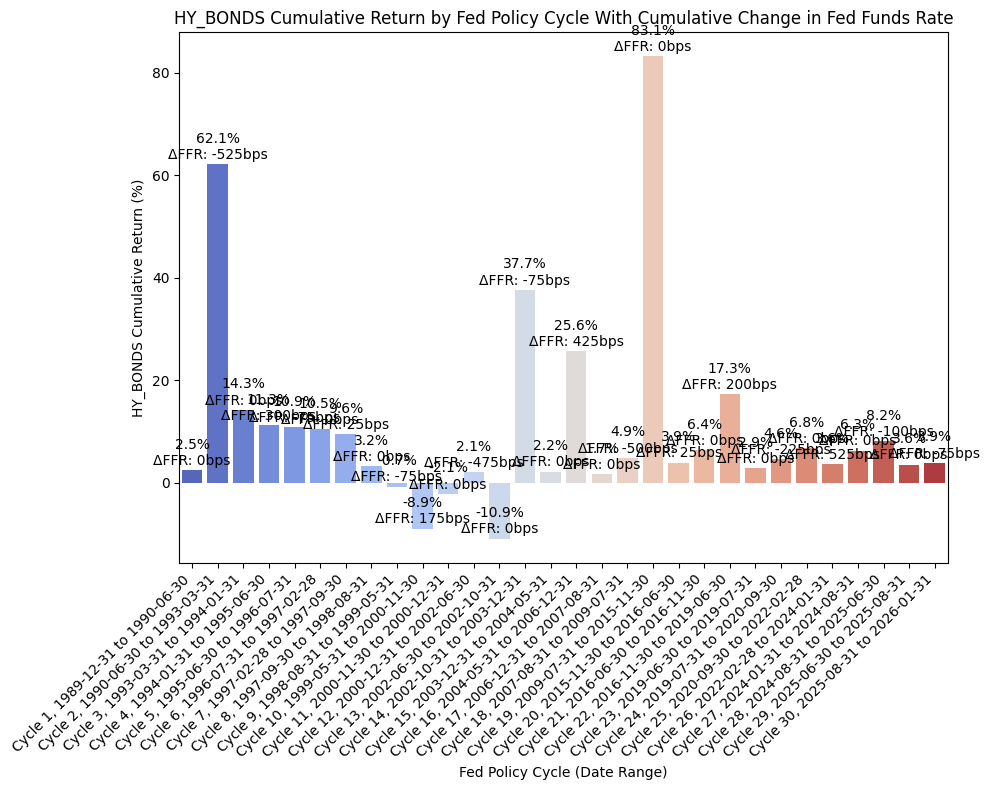

In [28]:
plot_bar_returns_ffr_change(
    cycle_df=hy_bonds_cycles,
    asset_label="HY_BONDS",
    annualized_or_cumulative="Cumulative",
)

And then the annualized returns along with the annualized change in FFR:

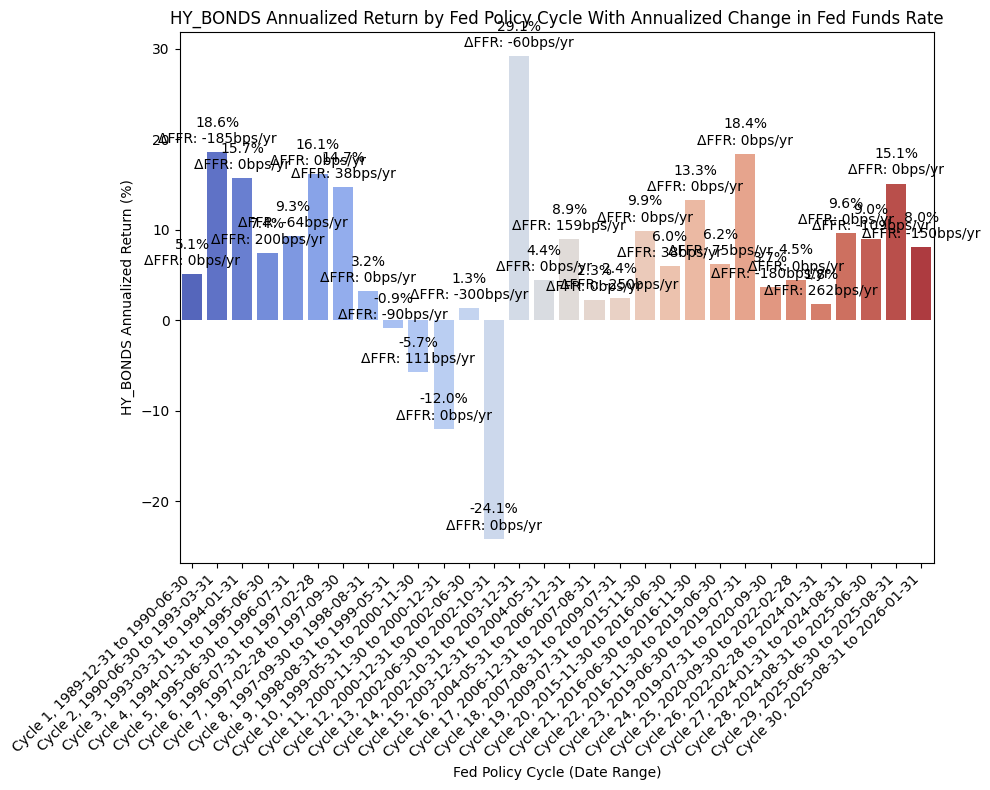

In [29]:
plot_bar_returns_ffr_change(
    cycle_df=hy_bonds_cycles,
    asset_label="HY_BONDS",
    annualized_or_cumulative="Annualized",
)

Finally, we can run an OLS regression to check fit:

In [30]:
df = hy_bonds_cycles

#=== Don't modify below this line ===

# Run OLS regression with statsmodels
X = df["FFR_AnnualizedChange_bps"]
y = df["AnnualizedReturnPct"]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())
print(f"Intercept: {model.params[0]}, Slope: {model.params[1]}")  # Intercept and slope

# Calc X and Y values for regression line
X_vals = np.linspace(X.min(), X.max(), 100)
Y_vals = model.params[0] + model.params[1] * X_vals

                             OLS Regression Results                            
Dep. Variable:     AnnualizedReturnPct   R-squared:                       0.004
Model:                             OLS   Adj. R-squared:                 -0.031
Method:                  Least Squares   F-statistic:                    0.1171
Date:                 Tue, 24 Feb 2026   Prob (F-statistic):              0.735
Time:                         14:11:36   Log-Likelihood:                -110.57
No. Observations:                   30   AIC:                             225.1
Df Residuals:                       28   BIC:                             227.9
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const         

And then plot the regression line along with the values:

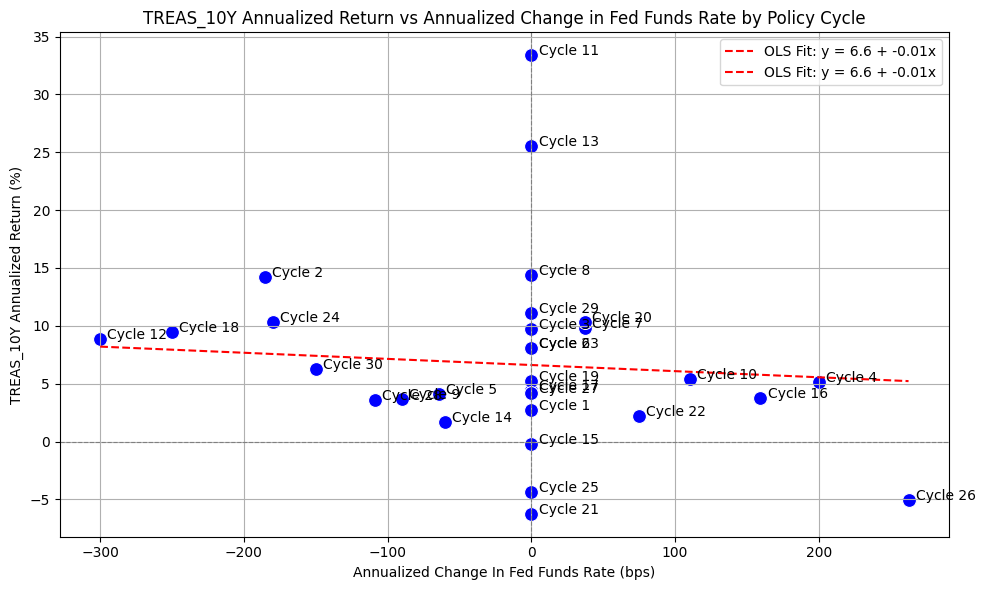

In [31]:
plot_scatter_regression_ffr_vs_returns(
    cycle_df=treas_10y_cycles,
    asset_label="TREAS_10Y",
    x_vals=X_vals,
    y_vals=Y_vals,
    intercept=model.params[0],
    slope=model.params[1],
)

### Gold

Finally, we'll run a similar process for gold using XAU_Gold USD Spot.

First, we pull data with the following:

In [32]:
bb_clean_data(
    base_directory=DATA_DIR,
    fund_ticker_name="XAU_Gold USD Spot",
    source="Bloomberg",
    asset_class="Commodities",
    excel_export=True,
    pickle_export=True,
    output_confirmation=False,
)

gold = load_data(
    base_directory=DATA_DIR,
    ticker="XAU_Gold USD Spot_Clean",
    source="Bloomberg", 
    asset_class="Commodities",
    timeframe="Daily",
    file_format="pickle",
)

# Filter GOLD to date range
gold = gold[(gold.index >= pd.to_datetime(start_date)) & (gold.index <= pd.to_datetime(end_date))]

# Drop everything except the "close" column
gold = gold[["Close"]]

# Resample to monthly frequency
gold_monthly = gold.resample("M").last()
gold_monthly["Monthly_Return"] = gold_monthly["Close"].pct_change()
gold_monthly = gold_monthly.dropna()

display(gold_monthly)

,Close,Monthly_Return
Date,,
1990-01-31,415.05000,0.03439
1990-02-28,407.70000,-0.01771
1990-03-31,368.50000,-0.09615
1990-04-30,367.75000,-0.00204
1990-05-31,363.05000,-0.01278
...,...,...
2025-09-30,3858.96000,0.11920
2025-10-31,4002.92000,0.03731
2025-11-30,4239.43000,0.05908


Next, we can plot the price history before calculating the cycle performance:

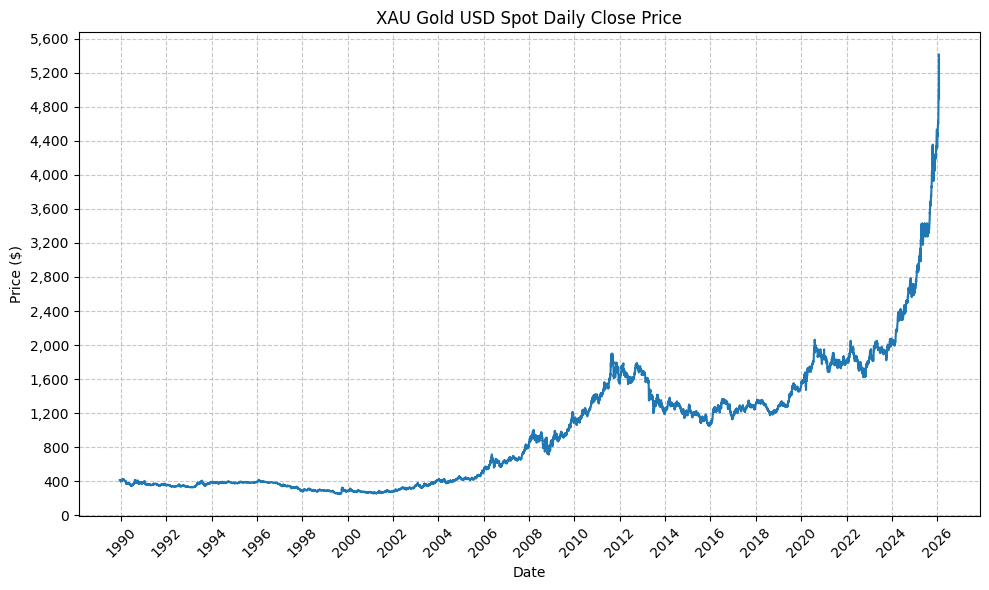

In [33]:
plot_timeseries(
    price_df=gold,
    plot_start_date=None,
    plot_end_date=None,
    plot_columns=["Close"],
    title="XAU Gold USD Spot Daily Close Price",
    x_label="Date",
    x_format="Year",
    x_tick_spacing=2,
    x_tick_rotation=45,
    y_label="Price ($)",
    y_format="Decimal",
    y_format_decimal_places=0,
    y_tick_spacing=400,
    grid=True,
    legend=False,
    export_plot=False,
    plot_file_name=None,
)

Next, we will calculate the performance of gold based on the pre-defined Fed cycles:

In [34]:
gold_cycles = calc_fed_cycle_asset_performance(
    start_date=cycle_ranges["start_date"],
    end_date=cycle_ranges["end_date"],
    label=cycle_ranges["cycle_label"],
    fed_funds_change=cycle_ranges["fed_funds_change"],
    monthly_returns=gold_monthly,
)

display(gold_cycles)

,Cycle,Start,End,Months,CumulativeReturn,CumulativeReturnPct,AverageMonthlyReturn,AverageMonthlyReturnPct,AnnualizedReturn,AnnualizedReturnPct,Volatility,FedFundsChange,FedFundsChange_bps,FFR_AnnualizedChange,FFR_AnnualizedChange_bps,Label
0,Cycle 1,1989-12-31,1990-06-30,6,-0.12224,-12.22430,-0.02069,-2.06945,-0.22954,-22.95426,0.14885,0.00000,0.00000,0.00000,0.00000,"Cycle 1, 1989-12-31 to 1990-06-30"
1,Cycle 2,1990-06-30,1993-03-31,34,-0.06624,-6.62443,-0.00158,-0.15839,-0.02390,-2.39005,0.10292,-0.05250,-525.00000,-0.01853,-185.29412,"Cycle 2, 1990-06-30 to 1993-03-31"
2,Cycle 3,1993-03-31,1994-01-31,11,0.15903,15.90288,0.01462,1.46238,0.17468,17.46838,0.17075,0.00000,0.00000,0.00000,0.00000,"Cycle 3, 1993-03-31 to 1994-01-31"
3,Cycle 4,1994-01-31,1995-06-30,18,-0.01561,-1.56130,-0.00070,-0.06966,-0.01044,-1.04359,0.06717,0.03000,300.00000,0.02000,200.00000,"Cycle 4, 1994-01-31 to 1995-06-30"
4,Cycle 5,1995-06-30,1996-07-31,14,0.00716,0.71559,0.00066,0.06552,0.00613,0.61305,0.06186,-0.00750,-75.00000,-0.00643,-64.28571,"Cycle 5, 1995-06-30 to 1996-07-31"
5,Cycle 6,1996-07-31,1997-02-28,8,-0.04468,-4.46839,-0.00519,-0.51936,-0.06627,-6.62715,0.11737,0.00000,0.00000,0.00000,0.00000,"Cycle 6, 1996-07-31 to 1997-02-28"
6,Cycle 7,1997-02-28,1997-09-30,8,-0.02875,-2.87498,-0.00313,-0.31292,-0.04281,-4.28133,0.11886,0.00250,25.00000,0.00375,37.50000,"Cycle 7, 1997-02-28 to 1997-09-30"
7,Cycle 8,1997-09-30,1998-08-31,12,-0.14993,-14.99306,-0.01285,-1.28489,-0.14993,-14.99306,0.12433,0.00000,0.00000,0.00000,0.00000,"Cycle 8, 1997-09-30 to 1998-08-31"
8,Cycle 9,1998-08-31,1999-05-31,10,-0.05621,-5.62053,-0.00517,-0.51718,-0.06706,-6.70614,0.12709,-0.00750,-75.00000,-0.00900,-90.00000,"Cycle 9, 1998-08-31 to 1999-05-31"
9,Cycle 10,1999-05-31,2000-11-30,19,-0.05619,-5.61857,-0.00193,-0.19269,-0.03586,-3.58627,0.17333,0.01750,175.00000,0.01105,110.52632,"Cycle 10, 1999-05-31 to 2000-11-30"


This gives us the following data points:

* Cycle start date
* Cycle end date
* Number of months in the cycle
* Cumulative return during the cycle (decimal and percent)
* Average monthly return during the cycle (decimal and percent)
* Annualized return during the cycle (decimal and percent)
* Return volatility during the cycle
* Cumulative change in FFR during the cycle (decimal and basis points)
* Annualized change in FFR during the cycle (decimal and basis points)

From the above DataFrame, we can then plot the cumulative and annualized returns for each cycle in a bar chart. First, the cumulative returns along with the cumulative change in FFR:

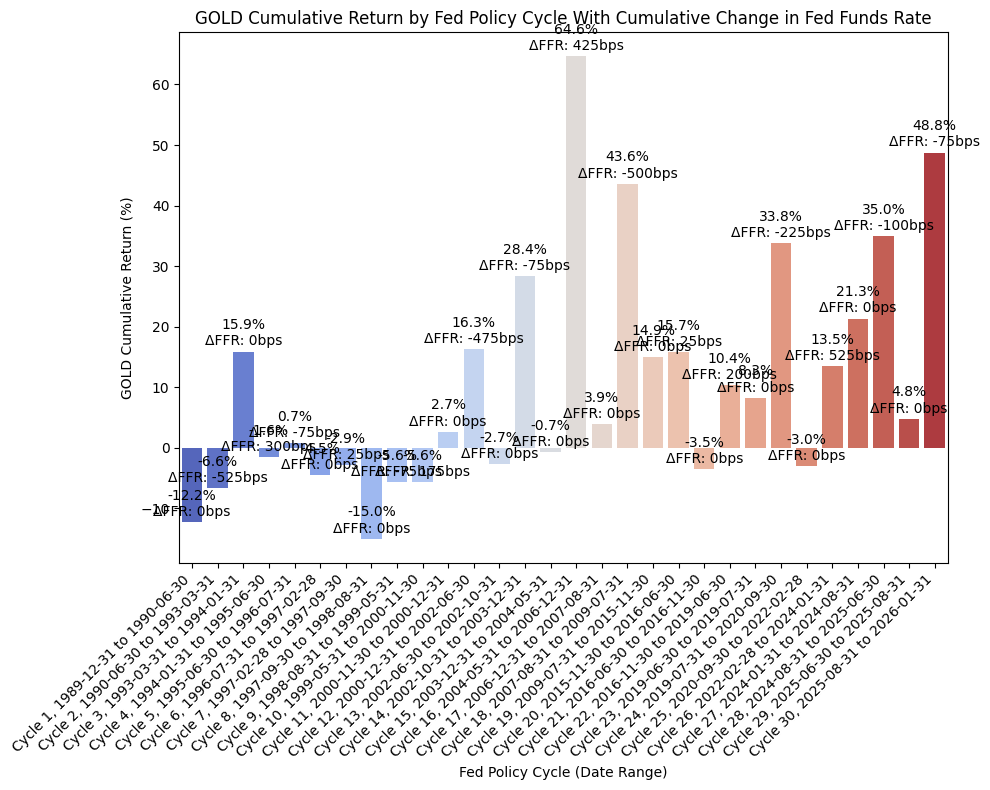

In [35]:
plot_bar_returns_ffr_change(
    cycle_df=gold_cycles,
    asset_label="GOLD",
    annualized_or_cumulative="Cumulative",
)

And then the annualized returns along with the annualized change in FFR:

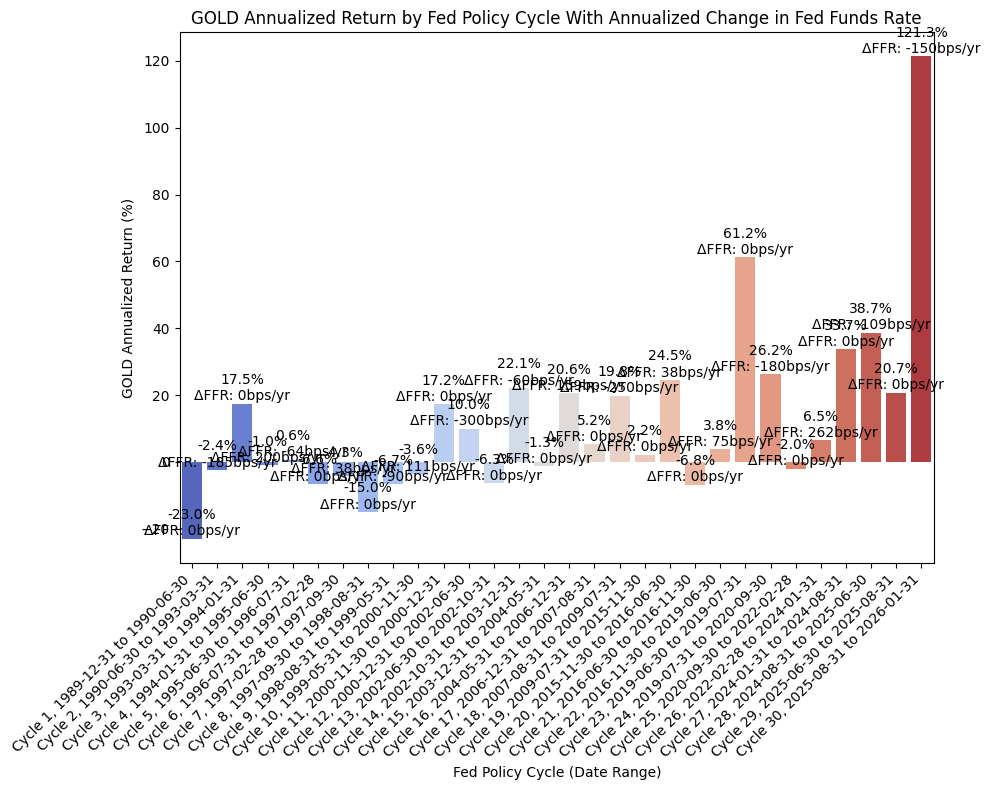

In [36]:
plot_bar_returns_ffr_change(
    cycle_df=gold_cycles,
    asset_label="GOLD",
    annualized_or_cumulative="Annualized",
)

We see strong returns for gold across several different Fed cycles, so it is difficult to draw any kind of initial conclusion based on the bar charts.

Finally, we can run an OLS regression to check fit:

In [37]:
df = gold_cycles

#=== Don't modify below this line ===

# Run OLS regression with statsmodels
X = df["FFR_AnnualizedChange_bps"]
y = df["AnnualizedReturnPct"]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())
print(f"Intercept: {model.params[0]}, Slope: {model.params[1]}")  # Intercept and slope

# Calc X and Y values for regression line
X_vals = np.linspace(X.min(), X.max(), 100)
Y_vals = model.params[0] + model.params[1] * X_vals

                             OLS Regression Results                            
Dep. Variable:     AnnualizedReturnPct   R-squared:                       0.064
Model:                             OLS   Adj. R-squared:                  0.030
Method:                  Least Squares   F-statistic:                     1.900
Date:                 Tue, 24 Feb 2026   Prob (F-statistic):              0.179
Time:                         14:11:39   Log-Likelihood:                -140.03
No. Observations:                   30   AIC:                             284.1
Df Residuals:                       28   BIC:                             286.9
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const         

And then plot the regression line along with the values:

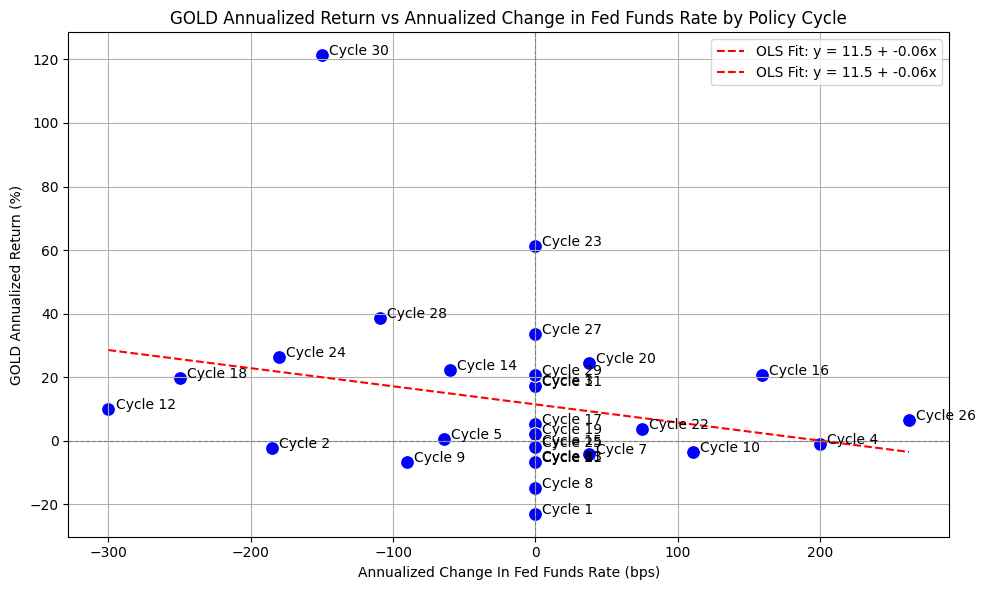

In [38]:
plot_scatter_regression_ffr_vs_returns(
    cycle_df=gold_cycles,
    asset_label="GOLD",
    x_vals=X_vals,
    y_vals=Y_vals,
    intercept=model.params[0],
    slope=model.params[1],
)

It's difficult to draw any strong conclusions with the above plot. Gold has traditionally been considered a hedge for inflation, and while one of the Fed's mandates is to manage inflation, there may not be a conclusion to draw in relationship to the historical returns that gold has exhibited.

## Asset Allocation

With the above analysis (somewhat) complete, let's look at the optimal allocation for a portfolio based on the data and the hypythetical historical results.

We have to be careful with our criteria for when to hold stocks, bonds, or gold, as hindsight bias is certainly possible. So, without overanalyzing the results, let's assume that we hold stocks as the default position during tightening cycles, and then hold bonds during easing cycles when the Fed starts cutting rates, and then resume holding stocks when the Fed stops cutting rates. If there is not any change in FFR, then we still hold stocks.

We can then combine the return series based on the above with the following:

In [39]:
# Shift the "cycle_filled" column down by one row to create a new column called "cycle_invested" that represents the cycle label that an investor would be invested in for each month (i.e. the cycle label from the previous month)

fedfunds_grouped_cycles['cycle_invested'] = fedfunds_grouped_cycles['cycle_filled'].shift(1)

display(fedfunds_grouped_cycles)

,start_date,fed_funds_start,end_date,fed_funds_end,fed_funds_change,cycle,cycle_filled,group,cycle_invested
0,1989-12-31,0.08250,1990-01-31,0.08250,0.00000,Neutral,Modified Tightening,1,None
1,1990-01-31,0.08250,1990-02-28,0.08250,0.00000,Neutral,Modified Tightening,1,Modified Tightening
2,1990-02-28,0.08250,1990-03-31,0.08250,0.00000,Neutral,Modified Tightening,1,Modified Tightening
3,1990-03-31,0.08250,1990-04-30,0.08250,0.00000,Neutral,Modified Tightening,1,Modified Tightening
4,1990-04-30,0.08250,1990-05-31,0.08250,0.00000,Neutral,Modified Tightening,1,Modified Tightening
...,...,...,...,...,...,...,...,...,...
429,2025-09-30,0.04250,2025-10-31,0.04000,-0.00250,Easing,Easing,30,Easing
430,2025-10-31,0.04000,2025-11-30,0.04000,0.00000,Neutral,Easing,30,Easing
431,2025-11-30,0.04000,2025-12-31,0.03750,-0.00250,Easing,Easing,30,Easing
432,2025-12-31,0.03750,2026-01-31,0.03750,0.00000,Neutral,Easing,30,Easing


In [40]:
# Reset index to merge on date
stocks_merged = pd.merge_asof(
    spxt_monthly.reset_index(),
    fedfunds_grouped_cycles[['start_date', 'end_date', 'cycle_invested', 'group']],
    left_on='Date',
    right_on='start_date',
    direction='backward'
)

# Drop rows where the date falls outside the cycle's end_date
stocks_merged = stocks_merged[stocks_merged['Date'] <= stocks_merged['end_date']]

display(stocks_merged)

,Date,Close,Monthly_Return,start_date,end_date,cycle_invested,group
0,1990-01-31,353.94000,-0.06713,1990-01-31,1990-02-28,Modified Tightening,1
1,1990-02-28,358.50000,0.01288,1990-02-28,1990-03-31,Modified Tightening,1
2,1990-03-31,368,0.02650,1990-03-31,1990-04-30,Modified Tightening,1
3,1990-04-30,358.81000,-0.02497,1990-04-30,1990-05-31,Modified Tightening,1
4,1990-05-31,393.80000,0.09752,1990-05-31,1990-06-30,Modified Tightening,1
...,...,...,...,...,...,...,...
427,2025-08-31,14304.68000,0.02027,2025-08-31,2025-09-30,Modified Tightening,30
428,2025-09-30,14826.80000,0.03650,2025-09-30,2025-10-31,Easing,30
429,2025-10-31,15173.95000,0.02341,2025-10-31,2025-11-30,Easing,30
430,2025-11-30,15211.14000,0.00245,2025-11-30,2025-12-31,Easing,30


In [41]:
# Reset index to merge on date
bonds_merged = pd.merge_asof(
    treas_10y_monthly.reset_index(),
    fedfunds_grouped_cycles[['start_date', 'end_date', 'cycle_invested', 'group']],
    left_on='Date',
    right_on='start_date',
    direction='backward'
)

# Drop rows where the date falls outside the cycle's end_date
bonds_merged = bonds_merged[bonds_merged['Date'] <= bonds_merged['end_date']]

display(bonds_merged)

,Date,Close,Monthly_Return,start_date,end_date,cycle_invested,group
0,1990-01-31,98.01300,-0.01987,1990-01-31,1990-02-28,Modified Tightening,1
1,1990-02-28,97.99000,-0.00023,1990-02-28,1990-03-31,Modified Tightening,1
2,1990-03-31,97.98900,-0.00001,1990-03-31,1990-04-30,Modified Tightening,1
3,1990-04-30,96.60600,-0.01411,1990-04-30,1990-05-31,Modified Tightening,1
4,1990-05-31,99.64700,0.03148,1990-05-31,1990-06-30,Modified Tightening,1
...,...,...,...,...,...,...,...
427,2025-08-31,641.25800,0.01668,2025-08-31,2025-09-30,Modified Tightening,30
428,2025-09-30,645.58400,0.00675,2025-09-30,2025-10-31,Easing,30
429,2025-10-31,650.00500,0.00685,2025-10-31,2025-11-30,Easing,30
430,2025-11-30,656.63600,0.01020,2025-11-30,2025-12-31,Easing,30


In [42]:
# Select the appropriate return based on cycle
stocks_merged['strategy_return'] = stocks_merged.apply(
    lambda row: row['Monthly_Return'] if row['cycle_invested'] in ['Tightening', 'Modified Tightening'] else None,
    axis=1
)

bonds_merged['strategy_return'] = bonds_merged.apply(
    lambda row: row['Monthly_Return'] if row['cycle_invested'] == 'Easing' else None,
    axis=1
)

# Combine
strategy = pd.concat([stocks_merged, bonds_merged]).dropna(subset=['strategy_return'])
strategy = strategy.sort_values('Date')

display(strategy.head(20))

,Date,Close,Monthly_Return,start_date,end_date,cycle_invested,group,strategy_return
0,1990-01-31,353.94000,-0.06713,1990-01-31,1990-02-28,Modified Tightening,1,-0.06713
1,1990-02-28,358.50000,0.01288,1990-02-28,1990-03-31,Modified Tightening,1,0.01288
2,1990-03-31,368,0.02650,1990-03-31,1990-04-30,Modified Tightening,1,0.02650
3,1990-04-30,358.81000,-0.02497,1990-04-30,1990-05-31,Modified Tightening,1,-0.02497
4,1990-05-31,393.80000,0.09752,1990-05-31,1990-06-30,Modified Tightening,1,0.09752
5,1990-06-30,391.14000,-0.00675,1990-06-30,1990-07-31,Modified Tightening,2,-0.00675
6,1990-07-31,102.84500,0.01463,1990-07-31,1990-08-31,Easing,2,0.01463
7,1990-08-31,100.78200,-0.02006,1990-08-31,1990-09-30,Easing,2,-0.02006
8,1990-09-30,101.74000,0.00951,1990-09-30,1990-10-31,Easing,2,0.00951
9,1990-10-31,103.65200,0.01879,1990-10-31,1990-11-30,Easing,2,0.01879


In [43]:
# Calculate cumulative returns and drawdown for spxt
spxt_monthly['Cumulative_Return'] = (1 + spxt_monthly['Monthly_Return']).cumprod() - 1
spxt_monthly['Cumulative_Return_Plus_One'] = 1 + spxt_monthly['Cumulative_Return']
spxt_monthly['Rolling_Max'] = spxt_monthly['Cumulative_Return_Plus_One'].cummax()
spxt_monthly['Drawdown'] = spxt_monthly['Cumulative_Return_Plus_One'] / spxt_monthly['Rolling_Max'] - 1
spxt_monthly.drop(columns=['Cumulative_Return_Plus_One', 'Rolling_Max'], inplace=True)

# Calculate cumulative returns and drawdown for treas_10y
treas_10y_monthly['Cumulative_Return'] = (1 + treas_10y_monthly['Monthly_Return']).cumprod() - 1
treas_10y_monthly['Cumulative_Return_Plus_One'] = 1 + treas_10y_monthly['Cumulative_Return']
treas_10y_monthly['Rolling_Max'] = treas_10y_monthly['Cumulative_Return_Plus_One'].cummax()
treas_10y_monthly['Drawdown'] = treas_10y_monthly['Cumulative_Return_Plus_One'] / treas_10y_monthly['Rolling_Max'] - 1
treas_10y_monthly.drop(columns=['Cumulative_Return_Plus_One', 'Rolling_Max'], inplace=True)

# Convert to DataFrame
portfolio_monthly = strategy[['Date', 'strategy_return']].copy().set_index('Date')
portfolio_monthly = portfolio_monthly.rename(columns={'strategy_return': 'Portfolio_Monthly_Return'})

# Calculate cumulative returns and drawdown for the portfolio
portfolio_monthly['Portfolio_Cumulative_Return'] = (1 + portfolio_monthly['Portfolio_Monthly_Return']).cumprod() - 1
portfolio_monthly['Portfolio_Cumulative_Return_Plus_One'] = 1 + portfolio_monthly['Portfolio_Cumulative_Return']
portfolio_monthly['Portfolio_Rolling_Max'] = portfolio_monthly['Portfolio_Cumulative_Return_Plus_One'].cummax()
portfolio_monthly['Portfolio_Drawdown'] = portfolio_monthly['Portfolio_Cumulative_Return_Plus_One'] / portfolio_monthly['Portfolio_Rolling_Max'] - 1
portfolio_monthly.drop(columns=['Portfolio_Cumulative_Return_Plus_One', 'Portfolio_Rolling_Max'], inplace=True)

# Merge "spxt_monthly" and "treas_10y_monthly" into "portfolio_monthly" to compare cumulative returns
portfolio_monthly = portfolio_monthly.join(
    spxt_monthly['Monthly_Return'].rename('SPXT_Monthly_Return'),
    how='left'
).join(
    spxt_monthly['Cumulative_Return'].rename('SPXT_Cumulative_Return'),
    how='left'
).join(
    spxt_monthly['Drawdown'].rename('SPXT_Drawdown'),
    how='left'
).join(
    treas_10y_monthly['Monthly_Return'].rename('10Y_Monthly_Return'),
    how='left'
).join(
    treas_10y_monthly['Cumulative_Return'].rename('10Y_Cumulative_Return'),
    how='left'
).join(
    treas_10y_monthly['Drawdown'].rename('10Y_Drawdown'),
    how='left'
)

In [44]:
display(portfolio_monthly)

,Portfolio_Monthly_Return,Portfolio_Cumulative_Return,Portfolio_Drawdown,SPXT_Monthly_Return,SPXT_Cumulative_Return,SPXT_Drawdown,10Y_Monthly_Return,10Y_Cumulative_Return,10Y_Drawdown
Date,,,,,,,,,
1990-01-31,-0.06713,-0.06713,0.00000,-0.06713,-0.06713,0.00000,-0.01987,-0.01987,0.00000
1990-02-28,0.01288,-0.05511,0.00000,0.01288,-0.05511,0.00000,-0.00023,-0.02010,-0.00023
1990-03-31,0.02650,-0.03007,0.00000,0.02650,-0.03007,0.00000,-0.00001,-0.02011,-0.00024
1990-04-30,-0.02497,-0.05429,-0.02497,-0.02497,-0.05429,-0.02497,-0.01411,-0.03394,-0.01436
1990-05-31,0.09752,0.03793,0.00000,0.09752,0.03793,0.00000,0.03148,-0.00353,0.00000
...,...,...,...,...,...,...,...,...,...
2025-08-31,0.02027,42.28506,0.00000,0.02027,36.70243,0.00000,0.01668,5.41258,-0.11316
2025-09-30,0.00675,42.57706,0.00000,0.03650,38.07857,0.00000,0.00675,5.45584,-0.10717
2025-10-31,0.00685,42.87548,0.00000,0.02341,38.99354,0.00000,0.00685,5.50005,-0.10106


Next, we'll look at performance for the assets and portfolio.

## Performance Statistics

We can then plot the monthly returns:

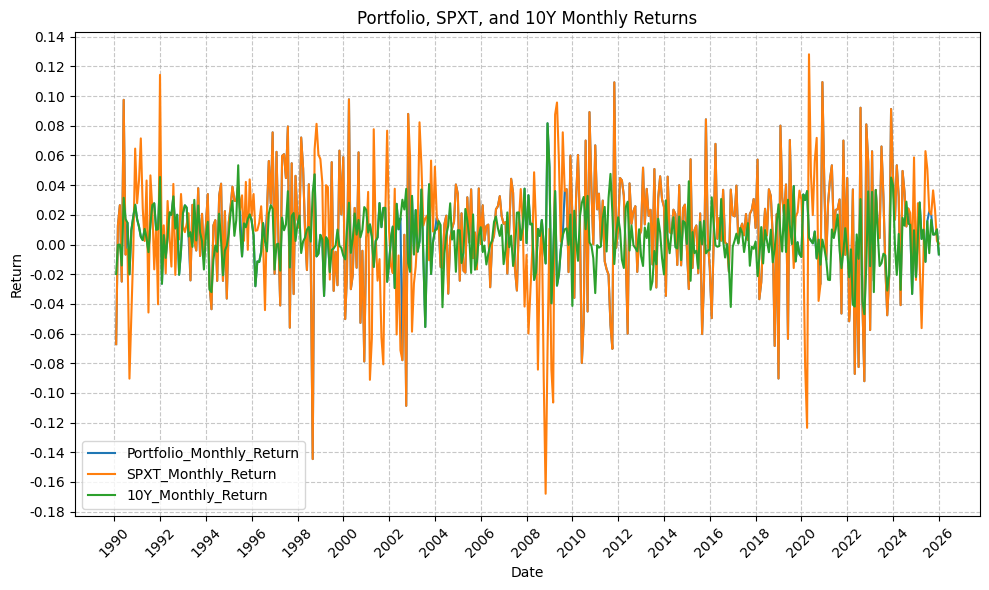

In [45]:
plot_timeseries(
    price_df=portfolio_monthly,
    plot_start_date=start_date,
    plot_end_date=end_date,
    plot_columns=["Portfolio_Monthly_Return", "SPXT_Monthly_Return", "10Y_Monthly_Return"],
    title="Portfolio, SPXT, and 10Y Monthly Returns",
    x_label="Date",
    x_format="Year",
    x_tick_spacing=2,
    x_tick_rotation=45,
    y_label="Return",
    y_format="Decimal",
    y_format_decimal_places=2,
    y_tick_spacing=0.02,
    grid=True,
    legend=True,
    export_plot=False,
    plot_file_name=None,
)

And cumulative returns:

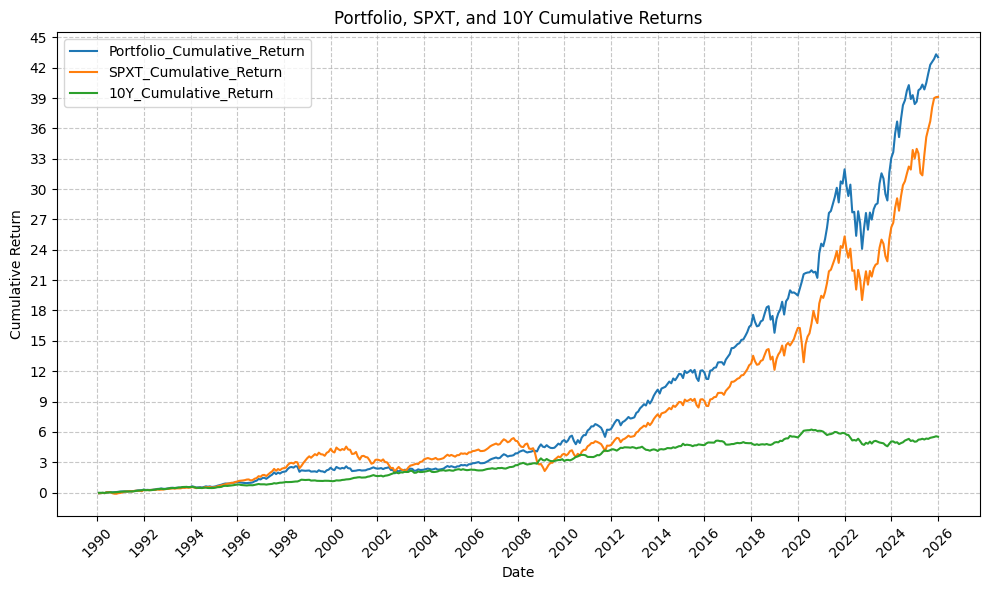

In [46]:
plot_timeseries(
    price_df=portfolio_monthly,
    plot_start_date=start_date,
    plot_end_date=end_date,
    plot_columns=["Portfolio_Cumulative_Return", "SPXT_Cumulative_Return", "10Y_Cumulative_Return"],
    title="Portfolio, SPXT, and 10Y Cumulative Returns",
    x_label="Date",
    x_format="Year",
    x_tick_spacing=2,
    x_tick_rotation=45,
    y_label="Cumulative Return",
    y_format="Decimal",
    y_format_decimal_places=0,
    y_tick_spacing=3,
    grid=True,
    legend=True,
    export_plot=False,
    plot_file_name=None,
)

And drawdowns:

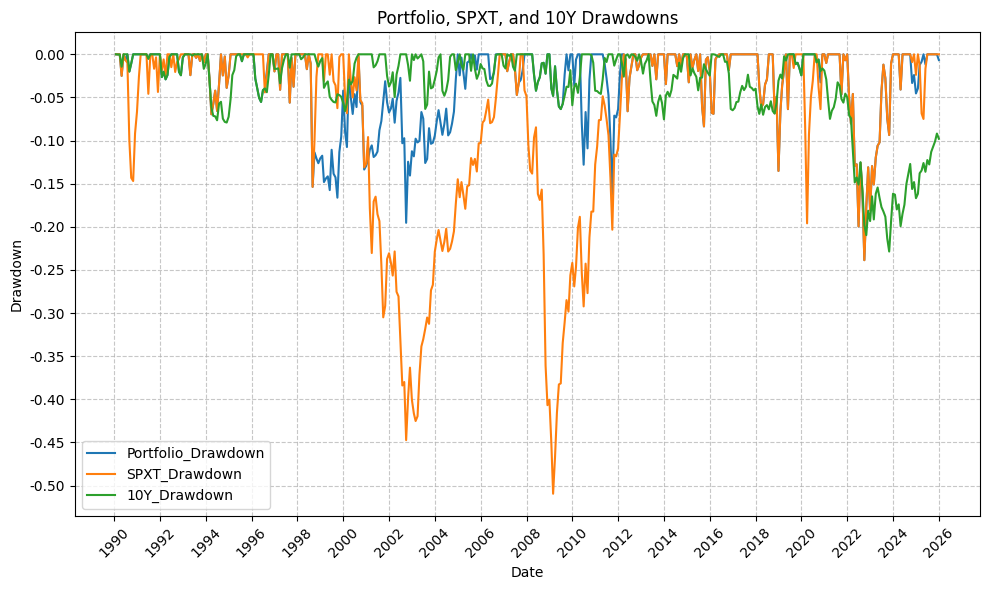

In [47]:
plot_timeseries(
    price_df=portfolio_monthly,
    plot_start_date=start_date,
    plot_end_date=end_date,
    plot_columns=["Portfolio_Drawdown", "SPXT_Drawdown", "10Y_Drawdown"],
    title="Portfolio, SPXT, and 10Y Drawdowns",
    x_label="Date",
    x_format="Year",
    x_tick_spacing=2,
    x_tick_rotation=45,
    y_label="Drawdown",
    y_format="Decimal",
    y_format_decimal_places=2,
    y_tick_spacing=0.05,
    grid=True,
    legend=True,
    export_plot=False,
    plot_file_name=None,
)

Finally, we can run the summary statistics on the strategy portfolio, SPY, and TLT with the following code:

In [48]:
port_sum_stats = summary_stats(
    fund_list=["Portfolio", "SPXT", "10Y"],
    df=portfolio_monthly[["Portfolio_Monthly_Return"]],
    period="Monthly",
    use_calendar_days=False,
    excel_export=False,
    pickle_export=False,
    output_confirmation=False,
)

spy_sum_stats = summary_stats(
    fund_list=["Portfolio", "SPXT", "10Y"],
    df=portfolio_monthly[["SPXT_Monthly_Return"]],
    period="Monthly",
    use_calendar_days=False,
    excel_export=False,
    pickle_export=False,
    output_confirmation=False,
)

tlt_sum_stats = summary_stats(
    fund_list=["Portfolio", "SPXT", "10Y"],
    df=portfolio_monthly[["10Y_Monthly_Return"]],
    period="Monthly",
    use_calendar_days=False,
    excel_export=False,
    pickle_export=False,
    output_confirmation=False,
)

sum_stats = pd.concat([port_sum_stats, spy_sum_stats, tlt_sum_stats])
sum_stats

,Annual Mean Return (Arithmetic),Annualized Volatility,Annualized Sharpe Ratio,CAGR (Geometric),Monthly Max Return,Monthly Max Return (Date),Monthly Min Return,Monthly Min Return (Date),Max Drawdown,Peak,Trough,Recovery Date,Days to Recovery,MAR Ratio
Portfolio_Monthly_Return,0.11267,0.11897,0.94701,0.11086,0.10946,2020-11-30,-0.14458,1998-08-31,-0.23867,2021-12-31,2022-09-30,2023-12-31,457.00000,0.46449
SPXT_Monthly_Return,0.11392,0.14735,0.77311,0.10799,0.12819,2020-04-30,-0.16795,2008-10-31,-0.50949,2007-10-31,2009-02-28,2012-03-31,1127.00000,0.21196
10Y_Monthly_Return,0.05420,0.06331,0.85606,0.05347,0.08169,2008-11-30,-0.05558,2003-07-31,-0.22865,2020-07-31,2023-10-31,NaT,NaN,0.23386


Based on the above, our strategy portfolio outperforms both stocks and bonds, with lower drawdowns.

## Conclusions

This was a interesting exercise to evaluate the performance of different asset classes during Fed tightening and easing cycles. The results are not particularly surprising, but it is interesting to see the data and plots to confirm the economic intuition that stocks perform well during tightening cycles (economic strength) and bonds perform well during easing cycles (economic weakness). The results are certainly dependent on the specific time period or regime, and also on the assumption made for how to handle the periods of neutral policy (i.e. no change in FFR).

## Future Investigation

A couple of ideas sound intriguing for future investigation:

* Does a commodity index (such as GSCI) exhibit differing behavior than gold?
* How does leverage affect the returns that are observed for the strategy portfolio, stocks, and bonds?
* Do other Fed tightening/loosening cycles exhibit the same behavior for returns?

## References

1. https://fred.stlouisfed.org/series/DFEDTARU
2. https://fred.stlouisfed.org/series/DFEDTARL
3. https://fred.stlouisfed.org/series/DFEDTAR